# Probability on Data: Joint, Marginal, Conditional, Priors, Bayes Rule and a MAP Classifier

In the previous practical a dataset was a **matrix**: rows were samples, columns were features, and a
model was a vector we multiplied it by. Nothing in that picture said anything about *uncertainty*:
`Phi @ w` returns one number and offers no opinion about how much to trust it.

This notebook puts a **probability distribution** on the same kind of data and builds a classifier out
of it. Four connected ideas:

1. **Probability distributions on data**: turning columns of a table into distributions by counting
   (discrete) and by fitting (continuous).
2. **Joint, marginal and conditional probabilities**: a joint distribution is a *table of numbers that
   sums to 1*; marginalising is summing along an axis; conditioning is normalising a slice.
3. **Prior probabilities and Bayes rule**: how a belief held *before* seeing evidence is updated into a
   belief held *after* seeing it.
4. **A maximum-a-posteriori (MAP) classifier**: choose the class with the largest posterior. This is a
   complete, working classifier built from nothing but counting and Bayes rule.

Everything is plain NumPy and pandas so that each probability stays a visible array of numbers instead
of disappearing inside a library call.

**Notation used throughout**

| symbol | reads as | example |
|---|---|---|
| $P(A)$ | probability of $A$ | $P(\text{district} = \text{center})$ |
| $P(A, B)$ | **joint**: probability of $A$ *and* $B$ together | $P(\text{center}, \text{large})$ |
| $P(A \mid B)$ | **conditional**: probability of $A$ *given that* $B$ happened | $P(\text{expensive} \mid \text{center})$ |
| $P(C)$ | **prior**: belief about the class before seeing features | $P(\text{expensive}) = 0.36$ |
| $P(C \mid x)$ | **posterior**: belief about the class after seeing features $x$ | $P(\text{expensive} \mid x) = 0.91$ |

In [43]:
import numpy as np                      # arrays, random sampling, all the numerical work
import pandas as pd                     # tables, so distributions print with readable labels
import matplotlib.pyplot as plt         # every plot in this notebook

%matplotlib inline

rng = np.random.default_rng(7)          # one seeded generator: rerunning gives identical numbers
np.set_printoptions(precision=3, suppress=True)   # 3 decimals, no scientific notation
pd.set_option("display.precision", 3)             # same idea for DataFrames
plt.rcParams["figure.figsize"] = (6, 4)           # default plot size in inches
plt.rcParams["figure.dpi"] = 110                  # default resolution

**Line by line**

- `np.random.default_rng(7)` : the modern NumPy way to get random numbers. The `7` is the **seed**:
  it fixes the entire stream, so everyone in the room gets the same dataset and the same printed
  probabilities. `rng` is an object, and every draw is a method on it: `rng.normal(...)`,
  `rng.choice(...)`.
- Prefer `default_rng` over the older `np.random.seed(0)` plus `np.random.normal(...)` style. The old
  functions share one hidden global state; `rng` keeps its state local, so one cell cannot silently
  change the output of another.
- `np.set_printoptions(precision=3, suppress=True)` : display only. `suppress=True` prints `0.001`
  instead of `1.000e-03`, which matters here because probabilities are often small.
- The two `plt.rcParams` lines set a default size and sharpness for every figure, so no plot needs to
  repeat them.

---
## Part 0: The dataset, and the process that generated it

The same apartments as last time, but now generated by an explicit **probabilistic process** rather
than typed by hand. This is deliberate: because we *choose* the true probabilities, we can later
compare what the data estimates against the truth and see how close counting gets us.

The generative story, in order:

1. Draw the class $C \in \{0, 1\}$ (`0` = affordable, `1` = expensive) from the **prior**
   $P(C = 1) = 0.35$.
2. **Given** that class, draw the district from a categorical distribution $P(\text{district} \mid C)$.
3. **Given** that class, draw `area_m2` from a Gaussian $\mathcal{N}(\mu_C, \sigma_C^2)$.
4. **Given** that class, draw `age_yrs` from another Gaussian.

Read step 1 as the prior and steps 2–4 as the **likelihood**. Those are exactly the two ingredients
Bayes rule needs, which is why the classifier in Part 4 is able to work backwards from the features to
the class. Note the direction: the generator goes $C \rightarrow x$, while the classifier goes
$x \rightarrow C$. **Bayes rule is the tool for reversing that arrow.**

In [44]:
N = 400                                            # number of apartments to generate

DISTRICTS = ["center", "suburb", "industrial"]     # the vocabulary of the categorical feature
CLASS_NAMES = ["affordable", "expensive"]          # class 0 and class 1, in index order

TRUE_PRIOR = np.array([0.65, 0.35])                # P(C=0), P(C=1): the true prior

TRUE_P_DISTRICT = {                                # P(district | C), one row per class
    0: np.array([0.15, 0.45, 0.40]),               # affordable: mostly suburb/industrial
    1: np.array([0.60, 0.30, 0.10]),               # expensive : mostly center
}

TRUE_AREA = {0: (65.0, 18.0), 1: (105.0, 22.0)}    # (mean, std) of area_m2 given each class
TRUE_AGE = {0: (22.0, 12.0), 1: (8.0, 6.0)}        # (mean, std) of age_yrs given each class

labels = rng.choice([0, 1], size=N, p=TRUE_PRIOR)  # step 1: draw N class labels from the prior

area = np.empty(N)                                 # empty containers to fill in class by class
age = np.empty(N)
district = np.empty(N, dtype=object)               # dtype=object because these are Python strings

for c in (0, 1):                                   # handle one class at a time
    mask = labels == c                             # boolean array: True where the label equals c
    k = int(mask.sum())                            # how many apartments fall in this class
    mu_a, sd_a = TRUE_AREA[c]                      # unpack that class's area parameters
    mu_g, sd_g = TRUE_AGE[c]                       # unpack that class's age parameters
    area[mask] = rng.normal(mu_a, sd_a, size=k)    # steps 3: k Gaussian draws written into those slots
    age[mask] = rng.normal(mu_g, sd_g, size=k)     # step 4: same for age
    district[mask] = rng.choice(DISTRICTS, size=k, p=TRUE_P_DISTRICT[c])   # step 2

area = np.clip(area, 25, None).round(1)            # no apartment smaller than 25 m2; 1 decimal
age = np.clip(age, 0, None).round(0)               # no negative ages; whole years

df = pd.DataFrame({                                # assemble everything into one table
    "area_m2": area,
    "age_yrs": age,
    "district": pd.Categorical(district, categories=DISTRICTS),   # fixes the column order
    "expensive": labels,
})

print("dataset shape:", df.shape)                  # (rows, columns) = (400, 4)
df.head(8)                                         # the first 8 rows, rendered as a table

dataset shape: (400, 4)


,area_m2,age_yrs,district,expensive
0,39.0,19.0,suburb,0
1,156.5,9.0,center,1
2,86.3,9.0,center,1
3,79.3,35.0,center,0
4,61.6,11.0,suburb,0
5,102.3,5.0,center,1
6,68.9,12.0,suburb,0
7,101.4,8.0,suburb,1


**Line by line**

- `TRUE_PRIOR = np.array([0.65, 0.35])`: a probability distribution over two outcomes is just a vector
  of two non-negative numbers that sums to 1. Index `0` is the probability of class 0. Everything in
  this notebook keeps that convention: **position in the array = which outcome**.
- `TRUE_P_DISTRICT` : a dictionary of vectors, one per class. Each vector sums to 1 on its own, because
  each is a distribution over districts *given* a fixed class. Stacked together they form the
  $2 \times 3$ **likelihood table** we will re-estimate from data in Part 4.
- `rng.choice([0, 1], size=N, p=TRUE_PRIOR)`: draws `N` values from `[0, 1]` with the given
  probabilities. This single line is "sample the class from the prior", repeated 400 times.
- `np.empty(N)` : allocates an uninitialised array of length `N`. Faster than building a list, and we
  overwrite every slot below anyway. Using `dtype=object` for `district` lets NumPy store strings.
- `mask = labels == c` : a **boolean mask**, not a number: an array of 400 `True`/`False` values.
  `area[mask] = ...` writes only into the positions where the mask is `True`, which is how we give each
  class its own parameters without a Python loop over the 400 rows.
- `rng.normal(mu, sd, size=k)` :`k` draws from the Gaussian (normal) distribution with that mean and
  standard deviation. This is the **class-conditional** distribution $P(\text{area} \mid C = c)$ that the
  classifier will later have to estimate.
- `np.clip(area, 25, None)` : clamps values below 25 up to 25 and leaves the upper end alone
  (`None` = no upper bound). A Gaussian technically allows negative areas; clipping keeps the data
  physically sensible.
- `pd.Categorical(district, categories=DISTRICTS)` : tells pandas that this column has a fixed set of
  values in a fixed order. Without it, every table below would silently sort districts alphabetically
  and `center, suburb, industrial` would come out as `center, industrial, suburb`.
- `df.head(8)` as the **last line** of the cell: Jupyter automatically displays the value of the final
  expression, which is why this prints as a formatted table rather than raw text.

In [45]:
print("class counts (how many of each label):")
print(df["expensive"].value_counts().sort_index())          # raw counts, sorted 0 then 1

print("\nclass proportions (counts divided by N):")
print(df["expensive"].value_counts(normalize=True).sort_index().round(3))

print("\ntrue prior used by the generator:", TRUE_PRIOR)

print("\nnumeric summary:")
df[["area_m2", "age_yrs"]].describe().round(2)

class counts (how many of each label):
expensive
0    256
1    144
Name: count, dtype: int64

class proportions (counts divided by N):
expensive
0    0.64
1    0.36
Name: proportion, dtype: float64

true prior used by the generator: [0.65 0.35]

numeric summary:


,area_m2,age_yrs
count,400.00,400.00
mean,78.05,16.99
std,27.94,12.06
min,25.00,0.00
25%,58.18,8.00
50%,72.80,16.00
75%,96.80,24.00
max,167.10,53.00


**Line by line**

- `value_counts()` : counts how many times each distinct value appears. This is *the* fundamental
  operation of the whole notebook: **every discrete probability below is a count divided by a total.**
- `value_counts(normalize=True)` : divides those counts by their sum, turning them into proportions
  that add to 1. That is already an estimated probability distribution.
- `.sort_index()` : orders by the label value (0 then 1) rather than by frequency, so the printed order
  matches `TRUE_PRIOR`.
- Compare the proportions to `TRUE_PRIOR`: close, but not identical. The generator used 0.35 and the
  sample landed near it. That gap is **sampling noise**, and it shrinks as $N$ grows — a fact worth
  testing yourself by re-running the generation cell with `N = 40` and `N = 40000`.
- `.describe()` : count, mean, std, min, quartiles and max for every numeric column at once. A quick
  sanity check that the numbers are in a plausible range before doing anything else with them.

---
## Part 1 — Probability distributions on data

A **probability distribution** assigns a non-negative number to each possible outcome so that the total
is 1. How we get those numbers depends on the type of the feature:

| feature type | object | how to estimate it | must satisfy |
|---|---|---|---|
| discrete (`district`) | probability **mass** function, PMF | count and divide | $\sum_k p_k = 1$ |
| continuous (`area_m2`) | probability **density** function, PDF | bin and divide, or fit a parametric shape | $\int p(x)\,dx = 1$ |

The distinction matters more than it looks, and Part 1c makes the difference concrete.

### 1a. A discrete distribution by counting

For a discrete feature the recipe is exactly two steps: **count each outcome, divide by the total.**
The result is called the **empirical distribution** — the distribution the data itself implies:

$$\hat{P}(\text{district} = v) = \frac{\#\{i : \text{district}_i = v\}}{n}$$

The hat on $\hat{P}$ is standard and important: it marks this as an *estimate computed from a sample*,
not the true underlying probability.

In [46]:
counts_district = np.array([                       # loop over the vocabulary in a fixed order
    np.sum(df["district"] == v)                    # np.sum of a boolean array counts the Trues
    for v in DISTRICTS
], dtype=float)                                    # float, so the division below is not integer division

n_total = counts_district.sum()                    # the grand total, which equals N here
pmf_district = counts_district / n_total           # counts -> probabilities: divide by the total

print("districts   :", DISTRICTS)
print("counts      :", counts_district)
print("PMF         :", pmf_district.round(3))
print("sums to 1   :", pmf_district.sum())         # the defining property of a distribution
print("all >= 0    :", np.all(pmf_district >= 0))  # the other defining property

pd.Series(pmf_district, index=DISTRICTS, name="P(district)").round(3)

districts   : ['center', 'suburb', 'industrial']
counts      : [134. 159. 107.]
PMF         : [0.335 0.398 0.268]
sums to 1   : 1.0
all >= 0    : True


center        0.335
suburb        0.398
industrial    0.268
Name: P(district), dtype: float64

**Line by line**

- `df["district"] == v` : comparing a column to a value gives a **boolean Series** of length 400, one
  `True`/`False` per row. It does not give a single answer.
- `np.sum(...)` on that boolean array counts the `True` values, because Python treats `True` as `1` and
  `False` as `0`. This is the counting trick that replaces an explicit loop.
- The list comprehension `[... for v in DISTRICTS]` runs the count once per district and keeps them in
  **our** order, not pandas' alphabetical order. Order discipline matters: `pmf_district[0]` must always
  mean `center`.
- `dtype=float` : without it the array is integer, and on integer arrays `/` would still work in Python 3
  but any later in-place operation could silently truncate. Being explicit avoids a class of bug that is
  painful to find.
- `counts_district / n_total` : NumPy divides every element by the scalar. **This one line is the entire
  definition of an empirical probability.**
- The two checks (`sums to 1`, `all >= 0`) are the axioms of probability. Get in the habit of asserting
  them: a distribution that does not sum to 1 is the single most common bug in this kind of code.
- `pd.Series(..., index=DISTRICTS)` : attaches the names so the printed output is self-explaining, the
  same trick used for the weight vector in the previous practical.

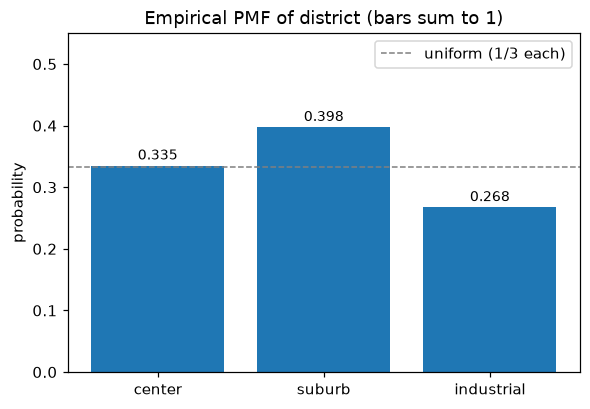

In [47]:
fig, ax = plt.subplots()                                        # one figure, one axes

bars = ax.bar(DISTRICTS, pmf_district, color="tab:blue")        # one bar per district

for bar, p in zip(bars, pmf_district):                          # walk bars and heights together
    ax.text(bar.get_x() + bar.get_width() / 2,                  # x: horizontal centre of the bar
            bar.get_height() + 0.01,                            # y: just above the top of the bar
            f"{p:.3f}",                                         # the label text, 3 decimals
            ha="center", fontsize=9)                            # ha = horizontal alignment

ax.axhline(1 / 3, ls="--", color="grey", lw=1,                  # reference line at 1/3
           label="uniform (1/3 each)")
ax.set_ylabel("probability")
ax.set_title("Empirical PMF of district (bars sum to 1)")
ax.set_ylim(0, 0.55)                                            # headroom so the labels are not clipped
ax.legend()
plt.show()

**Line by line**

- `ax.bar(DISTRICTS, pmf_district)` : categories on the x-axis, probabilities as bar heights. A PMF is
  naturally a bar chart: the outcomes are separate, so the bars do not touch.
- `zip(bars, pmf_district)` : pairs each drawn bar object with the number it represents, so the loop can
  place a text label on it.
- `bar.get_x() + bar.get_width() / 2` — `get_x()` is the bar's *left* edge, so adding half the width
  gives its centre. Combined with `ha="center"` the label sits exactly over the bar.
- `ax.axhline(1/3, ...)` : a horizontal reference line. Comparing the bars against it answers "is this
  distribution close to uniform?" at a glance: `suburb` is clearly above, `industrial` clearly below.
- `ax.set_ylim(0, 0.55)` : without the headroom the text labels on the tallest bars would be drawn
  outside the visible area and silently disappear.

### 1b. A continuous feature: from histogram to density

`area_m2` is continuous, so counting exact values is useless; almost every value occurs exactly once
and $\hat{P}(\text{area} = 78.3)$ would be $1/400$ for one particular number and $0$ everywhere else.
That is not a description of anything.

The fix is to stop asking about points and start asking about **intervals**. Chop the axis into bins,
count how many samples land in each, and divide. That gives a discrete distribution over bins:

$$\hat{P}(\text{area} \in \text{bin}_k) = \frac{\text{count}_k}{n}$$

Divide once more by the bin **width** and the bars become a **density**, whose *area* is 1 rather than
whose *heights* sum to 1. Density is the version that lets us compare a histogram against a fitted
curve, so it is the one we want.

In [48]:
bin_edges = np.arange(20, 190, 10.0)               # bin boundaries: 20, 30, ..., 180 (width 10)

counts, edges = np.histogram(df["area_m2"], bins=bin_edges)   # how many samples fall in each bin

bin_width = np.diff(edges)                         # width of every bin: differences of consecutive edges
bin_centers = (edges[:-1] + edges[1:]) / 2         # midpoint of each bin, for plotting

prob_per_bin = counts / counts.sum()               # probability mass in each bin: sums to 1
density_per_bin = prob_per_bin / bin_width         # mass divided by width: integrates to 1

print("number of bins       :", len(counts))
print("counts per bin       :", counts)
print("probabilities sum to :", prob_per_bin.sum().round(6))
print("density * width sums :", (density_per_bin * bin_width).sum().round(6))
print("\nlargest density value:", density_per_bin.max().round(4),
      "  <- a density, not a probability")

pd.DataFrame({
    "bin_start": edges[:-1],
    "bin_end": edges[1:],
    "count": counts,
    "P(bin)": prob_per_bin.round(3),
    "density": density_per_bin.round(4),
}).head(10)

number of bins       : 16
counts per bin       : [ 5 20 37 50 67 56 42 34 27 24 15 16  5  1  1  0]
probabilities sum to : 1.0
density * width sums : 1.0

largest density value: 0.0168   <- a density, not a probability


,bin_start,bin_end,count,P(bin),density
0,20.0,30.0,5,0.012,0.001
1,30.0,40.0,20,0.050,0.005
2,40.0,50.0,37,0.092,0.009
3,50.0,60.0,50,0.125,0.013
4,60.0,70.0,67,0.168,0.017
5,70.0,80.0,56,0.140,0.014
6,80.0,90.0,42,0.105,0.011
7,90.0,100.0,34,0.085,0.009
8,100.0,110.0,27,0.068,0.007
9,110.0,120.0,24,0.060,0.006


**Line by line**

- `np.arange(20, 190, 10.0)`: evenly spaced edges from 20 up to (but excluding) 190 in steps of 10.
  Choosing the edges by hand rather than passing `bins=15` keeps the bins fixed and comparable across
  re-runs.
- `np.histogram(data, bins=edges)`: returns **two** things: the counts and the edges that were used.
  It does *not* plot anything; it only computes. Unpacking both is why the line reads
  `counts, edges = ...`.
- `np.diff(edges)`: differences between consecutive elements, so 17 edges give 16 widths. **There is
  always one fewer bin than there are edges.** Writing the widths this way, rather than hard-coding
  `10`, keeps the code correct even for unequal bin widths.
- `(edges[:-1] + edges[1:]) / 2`: a standard idiom for midpoints: `edges[:-1]` is every edge except the
  last (the left edges), `edges[1:]` is every edge except the first (the right edges), and averaging them
  pairwise gives the centres.
- `counts / counts.sum()` : the same count-and-divide as in 1a. Now each number is the probability of
  landing in that bin.
- `prob_per_bin / bin_width`: the step that turns mass into **density**. The check
  `(density * width).sum() == 1` is the discrete version of $\int p(x)\,dx = 1$.

**The point of the last print.** The largest density value is well below 1 here, but there is no rule
saying it must be. Make the bins narrow enough and densities exceed 1 happily. **A density is not a
probability** — it is a probability *per unit of x*, and only becomes a probability once multiplied by a
width. This trips up almost everyone the first time.

### 1c. Fitting a parametric distribution

The histogram is honest but clumsy: 17 numbers to describe one column, all of them noisy, and it says
nothing about areas we have not observed. A **parametric** distribution replaces it with a formula and a
couple of numbers.

For a Gaussian (normal) distribution the formula is

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$$

and the two parameters have closed-form maximum-likelihood estimates that are just the sample mean and
sample standard deviation:

$$\hat{\mu} = \frac{1}{n}\sum_i x_i, \qquad \hat{\sigma}^2 = \frac{1}{n}\sum_i (x_i - \hat{\mu})^2$$

So "fitting a Gaussian" is two lines of code. Compare that with the previous practical, where fitting a
regression took a matrix inverse, or a logistic model, which needed 4000 gradient steps.

In [49]:
def gaussian_pdf(x, mu, sigma):
    '''Probability density of N(mu, sigma^2), evaluated elementwise at x.'''
    norm_const = 1.0 / np.sqrt(2.0 * np.pi * sigma ** 2)    # the 1/sqrt(2 pi sigma^2) factor
    exponent = -((x - mu) ** 2) / (2.0 * sigma ** 2)        # the -(x-mu)^2 / (2 sigma^2) term
    return norm_const * np.exp(exponent)                    # multiply them: the density


mu_area = df["area_m2"].mean()                     # maximum-likelihood estimate of mu
sigma_area = df["area_m2"].std(ddof=0)             # ddof=0 gives the MLE (divide by n, not n-1)

print(f"fitted mu    = {mu_area:.2f} m2")
print(f"fitted sigma = {sigma_area:.2f} m2")

grid = np.linspace(20, 185, 400)                   # 400 evenly spaced x values for a smooth curve
pdf_values = gaussian_pdf(grid, mu_area, sigma_area)   # the fitted density at each of them

area_under_plotted = np.trapezoid(pdf_values, grid)          # integral over the plotting range only

wide_grid = np.linspace(mu_area - 10 * sigma_area,           # 10 standard deviations either side
                        mu_area + 10 * sigma_area, 5000)     # far enough out to catch all the mass
area_under_all = np.trapezoid(gaussian_pdf(wide_grid, mu_area, sigma_area), wide_grid)

print(f"\narea under the curve over the plotted range 20 to 185 = {area_under_plotted:.4f}")
print(f"area under the curve over the full real line         = {area_under_all:.4f}")

fitted mu    = 78.05 m2
fitted sigma = 27.91 m2

area under the curve over the plotted range 20 to 185 = 0.9812
area under the curve over the full real line         = 1.0000


**Line by line**

- The docstring in `'''...'''` documents what the function returns. Every helper in this notebook has one.
- `norm_const` and `exponent` are split onto separate lines purely for readability — the formula written
  as one expression is correct but much harder to check against the printed maths above.
- `np.exp` (not `math.exp`) so the function works on a whole array of `x` values at once. That
  vectorisation is what lets one call evaluate the density at all 400 grid points.
- `df["area_m2"].std(ddof=0)` : **`ddof` matters.** `ddof=0` divides by $n$ and gives the
  maximum-likelihood estimate, which is what the formula above defines. `ddof=1` (the pandas default!)
  divides by $n-1$ and gives the unbiased sample estimate. At $n = 400$ the difference is invisible, but
  being explicit means the code matches the maths.
- `np.linspace(20, 185, 400)` : 400 equally spaced points, unlike `np.arange` which takes a step size.
  Use `linspace` when you care about how many points, `arange` when you care about the spacing.
- `np.trapezoid(y, x)` : the trapezoidal rule: approximates $\int y \, dx$ by summing the areas of
  trapezoids under the sampled curve. (On NumPy versions before 2.0 this function is spelled `np.trapz`.)
- **The two integrals differ, and the gap is the point.** Over the plotting range the answer is about
  0.98, not 1.00, because a Gaussian has tails stretching to infinity and roughly 2% of its mass lies
  outside 20–185. Integrating over ±10 standard deviations recovers 1.0000. A density only integrates to
  1 over its **whole** support, so an integral of 0.98 is not a bug — it is the honest statement that we
  looked at part of the axis.

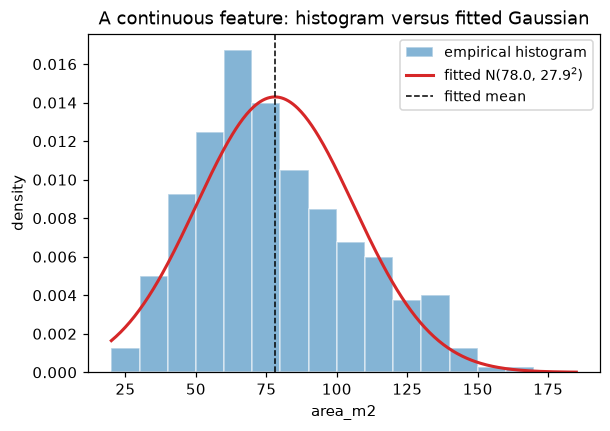

In [50]:
fig, ax = plt.subplots()

ax.hist(df["area_m2"], bins=bin_edges, density=True,            # density=True rescales to integrate to 1
        color="tab:blue", alpha=0.55, edgecolor="white",
        label="empirical histogram")

ax.plot(grid, pdf_values, color="tab:red", lw=2,                # the fitted parametric curve
        label=f"fitted N({mu_area:.1f}, {sigma_area:.1f}$^2$)")

ax.axvline(mu_area, ls="--", color="black", lw=1, label="fitted mean")

ax.set_xlabel("area_m2")
ax.set_ylabel("density")
ax.set_title("A continuous feature: histogram versus fitted Gaussian")
ax.legend(fontsize=9)
plt.show()

**Line by line**

- `density=True` inside `ax.hist` performs exactly the `counts / n / width` calculation we did by hand in
  1b. Without it the bars would be raw counts (heights near 50) and the density curve (heights near 0.01)
  would be invisible at the bottom of the plot. **Both objects must be on the same vertical scale for the
  comparison to mean anything.**
- `alpha=0.55` makes the bars semi-transparent so the red curve stays readable where they overlap.
- `edgecolor="white"` draws thin separators so adjacent bars are distinguishable.
- `f"...N({mu_area:.1f}, {sigma_area:.1f}$^2$)"` — an f-string containing LaTeX. Matplotlib renders text
  between `$` signs as maths, which is how the squared symbol appears in the legend.

**Reading the plot.** The fit is plausible but visibly wrong in a specific, systematic way. The
histogram peaks around 65 m² while the fitted curve peaks at its mean of 78 m². The curve therefore sits
**below** the bars from roughly 50 to 75 and **above** them from roughly 80 to 110, and the data trails
off to the right much further than a symmetric bell should.

That is not noise, and no amount of extra data would fix it. The column is a **mixture of two
distributions**, one per class and the mixture is right-skewed because the larger, cheaper group
forms the peak while the smaller, larger-apartment group drags the mean rightwards. A single symmetric
Gaussian cannot represent two overlapping humps. Part 4 fits one Gaussian *per class* instead, which is
both a better description of the data and the thing that makes classification possible.

In [51]:
lo, hi = 80.0, 100.0                               # the interval we want the probability of

mask_interval = (df["area_m2"] >= lo) & (df["area_m2"] < hi)   # & is elementwise AND on boolean arrays
empirical_prob = mask_interval.mean()              # mean of a boolean array = fraction of Trues

fine_grid = np.linspace(lo, hi, 500)               # a dense grid covering just that interval
model_prob = np.trapezoid(gaussian_pdf(fine_grid, mu_area, sigma_area), fine_grid)

density_at_90 = gaussian_pdf(90.0, mu_area, sigma_area)   # the density value at a single point

print(f"P({lo} <= area < {hi}) counted from data : {empirical_prob:.4f}")
print(f"P({lo} <= area < {hi}) from the Gaussian : {model_prob:.4f}")
print(f"\ndensity p(90.0)                          : {density_at_90:.4f}")
print("P(area == exactly 90.0) under the model  : 0.0")

P(80.0 <= area < 100.0) counted from data : 0.1900
P(80.0 <= area < 100.0) from the Gaussian : 0.2564

density p(90.0)                          : 0.0130
P(area == exactly 90.0) under the model  : 0.0


**Line by line**

- `(df["area_m2"] >= lo) & (df["area_m2"] < hi)` : two boolean arrays combined with `&`, which is
  elementwise AND. Use `&` and `|` on arrays, **never** `and` / `or`: the Python keywords try to reduce a
  whole array to a single truth value and raise `ValueError: truth value of an array is ambiguous`.
  The parentheses are also mandatory, because `&` binds tighter than `>=`.
- `mask_interval.mean()` : averaging `True`/`False` gives the proportion of `True`. Counting and dividing
  again, expressed in one call.
- `np.trapezoid(gaussian_pdf(fine_grid, ...), fine_grid)` — integrates the fitted density between the two
  limits. This is the model's answer to the same question the data answered by counting.
- **The two answers disagree, and by a lot**: about 0.19 from the data against about 0.26 from the model.
  Look back at the previous plot to see why. The window 80–100 is exactly where the red curve floats
  above the blue bars, so the model assigns that interval more probability than the data supports. **A
  fitted distribution is a claim about the data, and this one is measurably wrong in this region**; a
  useful reminder that "we fitted a Gaussian" is never the end of the story.
- `density_at_90` versus the final line, the crux of 1b restated. The density has a perfectly good value
  at a point, but the *probability* of any exact real value is zero, because an interval of zero width
  encloses zero area. Continuous distributions only assign probability to intervals.

---
## Part 2: Joint, marginal and conditional probabilities

Everything in this part is one object seen from three angles.

- The **joint** $P(A, B)$ is a *table*. Every cell is the probability of one combination, and the whole
  table sums to 1.
- A **marginal** $P(A)$ is a *row sum or column sum* of that table. The other variable is summed away.
- A **conditional** $P(A \mid B)$ is *one slice of the table, renormalised so that slice sums to 1*.

Written as formulas:

$$P(A) = \sum_b P(A, b) \qquad\qquad P(A \mid B) = \frac{P(A, B)}{P(B)} \qquad\qquad P(A, B) = P(A \mid B)\,P(B)$$

The last one is the **product rule**, and it is Bayes rule with one step still to go.

To have two discrete variables to work with we first turn the continuous `area_m2` into a discrete
`size_class`, using the bin-then-count idea from Part 1b.

In [52]:
SIZE_CLASSES = ["small", "medium", "large"]        # our chosen vocabulary, in increasing order

df["size_class"] = pd.cut(                         # pd.cut assigns each numeric value to a bin
    df["area_m2"],
    bins=[0, 60, 95, np.inf],                      # the cut points: (0,60], (60,95], (95,inf)
    labels=SIZE_CLASSES,                           # the name attached to each bin
)

print("counts per size class:")
print(df["size_class"].value_counts().reindex(SIZE_CLASSES))

df[["area_m2", "size_class", "district", "expensive"]].head(6)

counts per size class:
size_class
small     112
medium    183
large     105
Name: count, dtype: int64


,area_m2,size_class,district,expensive
0,39.0,small,suburb,0
1,156.5,large,center,1
2,86.3,medium,center,1
3,79.3,medium,center,0
4,61.6,medium,suburb,0
5,102.3,large,center,1


**Line by line**

- `pd.cut(series, bins=[...], labels=[...])` : bins a numeric column into named categories. The bins are
  half-open intervals `(left, right]`, so an apartment of exactly 60 m² is `small` and 60.1 m² is
  `medium`. Knowing which end is included matters when a boundary case appears in a marked exercise.
- `np.inf` as the last edge, positive infinity, so the top bin has no upper limit and no apartment can
  fall outside the bins and become `NaN`.
- `labels=SIZE_CLASSES` : without labels the column would contain interval objects like `(60.0, 95.0]`,
  which are correct but unpleasant to index tables with.
- `.reindex(SIZE_CLASSES)` : forces our order instead of pandas' default, the same discipline as before.

**A note on what binning costs.** A 96 m² and a 200 m² apartment are now both just `large`. We threw away
information to gain a variable we can count. That is the same trade made in the previous practical when
a continuous price was thresholded into an "expensive" label.

### 2a. The joint distribution as a table

$$\hat{P}(\text{district} = u, \text{size} = v) = \frac{\#\{i : \text{district}_i = u \text{ and } \text{size}_i = v\}}{n}$$

Count each **combination**, divide by $n$ once at the end. There are $3 \times 3 = 9$ combinations here,
so the joint is a $3 \times 3$ matrix whose 9 entries sum to 1.

In [53]:
joint_counts = np.zeros((len(DISTRICTS), len(SIZE_CLASSES)))      # a 3x3 grid of zeros to fill

for i, d_value in enumerate(DISTRICTS):                           # i indexes rows (district)
    for j, s_value in enumerate(SIZE_CLASSES):                    # j indexes columns (size)
        both_true = (df["district"] == d_value) & (df["size_class"] == s_value)
        joint_counts[i, j] = both_true.sum()                      # how many rows satisfy BOTH

joint = joint_counts / joint_counts.sum()          # divide by the grand total to get probabilities

joint_df = pd.DataFrame(joint, index=DISTRICTS, columns=SIZE_CLASSES)   # label the axes

print("counts (should total 400):", joint_counts.sum())
print("joint sums to 1          :", joint.sum().round(10))
print("shape                    :", joint.shape)
print()
print("P(district, size_class):")
joint_df.round(3)

counts (should total 400): 400.0
joint sums to 1          : 1.0
shape                    : (3, 3)

P(district, size_class):


,small,medium,large
center,0.055,0.122,0.158
suburb,0.118,0.192,0.088
industrial,0.108,0.142,0.018


**Line by line**

- `np.zeros((3, 3))` : the container. The tuple `(3, 3)` is the shape; passing `3, 3` as two arguments
  would mean something different and fail.
- `enumerate(DISTRICTS)` : yields `(0, "center"), (1, "suburb"), (2, "industrial")`, giving both the index
  for writing into the array and the value for comparing against the column.
- `(df["district"] == d_value) & (df["size_class"] == s_value)`: the **joint** condition. This single
  `&` is the entire difference between a joint and a marginal probability: we require both events at
  once, instead of one at a time.
- `joint_counts[i, j] = both_true.sum()` : cell `[i, j]` holds the count for row category `i` and column
  category `j`. Reading `joint[0, 2]` therefore means $P(\text{center}, \text{large})$.
- `joint_counts / joint_counts.sum()` : dividing by the **grand** total (not by row or column totals) is
  what makes this a joint distribution rather than a conditional one. Dividing by row totals instead is
  what we will do in 2c, and it produces a different object entirely.
- `joint.sum().round(10)` : for a 2-D array `.sum()` with no axis argument adds up *everything*, which is
  the check we want. Rounding to 10 places hides floating-point dust like `0.9999999999999999`.

In [54]:
crosstab_joint = pd.crosstab(                      # pandas does the double loop in one call
    df["district"],
    df["size_class"],
    normalize=True,                                # divide by the grand total
)

print("pd.crosstab result:")
print(crosstab_joint.round(3))
print("\nmatches the hand-built table:",
      np.allclose(crosstab_joint.to_numpy(), joint))

pd.crosstab result:
size_class  small  medium  large
district                        
center      0.055   0.122  0.158
suburb      0.118   0.192  0.088
industrial  0.108   0.142  0.018

matches the hand-built table: True


**Line by line**

- `pd.crosstab(a, b)` : builds the contingency table of two categorical Series: rows are the values of
  `a`, columns the values of `b`, cells the counts. Writing the loop first and this second is deliberate:
  once you have seen the nine `&` counts, `crosstab` stops being magic.
- `normalize=True` : divides by the grand total, giving the joint distribution. Two other options exist
  and are worth remembering: `normalize="index"` divides by row totals (giving $P(\text{size} \mid
  \text{district})$) and `normalize="columns"` divides by column totals.
- `np.allclose(a, b)` : compares float arrays with a tolerance rather than `==`, exactly as in the
  previous practical.

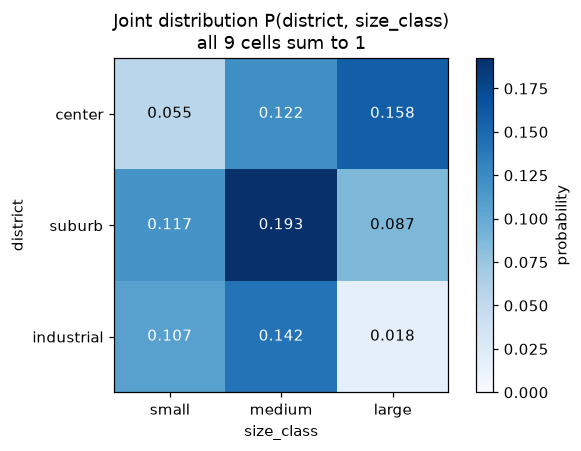

In [55]:
fig, ax = plt.subplots(figsize=(6, 4.2))

im = ax.imshow(joint, cmap="Blues", vmin=0)                  # the table drawn as a heatmap

for i in range(len(DISTRICTS)):                              # write the number inside each cell
    for j in range(len(SIZE_CLASSES)):
        value = joint[i, j]
        ax.text(j, i, f"{value:.3f}",                        # note: x is the COLUMN, y is the ROW
                ha="center", va="center",
                color="white" if value > joint.max() / 2 else "black")

ax.set_xticks(range(len(SIZE_CLASSES)))                      # put a tick at every column
ax.set_xticklabels(SIZE_CLASSES)
ax.set_yticks(range(len(DISTRICTS)))                         # and at every row
ax.set_yticklabels(DISTRICTS)
ax.set_xlabel("size_class")
ax.set_ylabel("district")
ax.set_title("Joint distribution P(district, size_class)\nall 9 cells sum to 1")
plt.colorbar(im, ax=ax, label="probability")
plt.tight_layout()
plt.show()

**Line by line**

- `ax.imshow(joint)` : draws a 2-D array as an image, one pixel per cell, colour proportional to value.
  `vmin=0` pins the bottom of the colour scale at zero so cell shading is comparable across plots.
- `ax.text(j, i, ...)` : the argument order is `(x, y)`, and in image coordinates **x is the column index
  and y is the row index**. Writing `ax.text(i, j, ...)` here would transpose every label, which is a
  classic silent bug.
- `color="white" if value > joint.max()/2 else "black"` : a conditional expression, so text stays legible
  on both dark and light cells.
- `ax.set_xticks(...)` before `ax.set_xticklabels(...)` : the ticks must exist before they can be named.
  Setting labels alone leads to labels landing on the wrong positions.

**Reading it.** The darkest cell is `(suburb, medium)`; `(industrial, large)` is nearly empty. Those are
statements about combinations, and no single-variable summary could have told you either of them.

### 2b. Marginals: summing a variable away

To get $P(\text{district})$ from the joint, add up everything the district could be paired with:

$$P(\text{district} = u) = \sum_{v \in \{\text{small},\text{medium},\text{large}\}} P(\text{district} = u, \text{size} = v)$$

This is called **marginalising out** the size, and the name is literal — these totals were traditionally
written in the margins of the printed table.

There is a direct link back to the previous practical. Summing along an axis is a **matrix–vector
product with a vector of ones**:

$$P(\text{district}) = J\mathbf{1}, \qquad P(\text{size}) = J^\top\mathbf{1}$$

so marginalisation is a linear operation on the joint table.

In [56]:
marg_district = joint.sum(axis=1)                  # sum ACROSS columns -> one number per row
marg_size = joint.sum(axis=0)                      # sum DOWN rows      -> one number per column

ones_cols = np.ones(len(SIZE_CLASSES))             # a vector of ones, length 3
ones_rows = np.ones(len(DISTRICTS))                # a vector of ones, length 3

marg_district_matmul = joint @ ones_cols           # (3,3) @ (3,) -> (3,)  same as sum(axis=1)
marg_size_matmul = joint.T @ ones_rows             # (3,3) @ (3,) -> (3,)  same as sum(axis=0)

print("P(district) by summing axis=1 :", marg_district.round(3))
print("P(district) by joint @ ones    :", marg_district_matmul.round(3))
print("identical:", np.allclose(marg_district, marg_district_matmul))
print()
print("P(size_class) by summing axis=0:", marg_size.round(3))
print("P(size_class) by joint.T @ ones:", marg_size_matmul.round(3))
print()
print("each marginal sums to 1:", marg_district.sum().round(6), marg_size.sum().round(6))
print()
print("cross-check against counting the single column directly:")
print("  from the joint  :", marg_district.round(4))
print("  counted directly:", np.array([np.mean(df['district'] == v) for v in DISTRICTS]).round(4))

P(district) by summing axis=1 : [0.335 0.397 0.268]
P(district) by joint @ ones    : [0.335 0.397 0.268]
identical: True

P(size_class) by summing axis=0: [0.28  0.458 0.262]
P(size_class) by joint.T @ ones: [0.28  0.458 0.262]

each marginal sums to 1: 1.0 1.0

cross-check against counting the single column directly:
  from the joint  : [0.335 0.398 0.268]
  counted directly: [0.335 0.398 0.268]


**Line by line**

- `joint.sum(axis=1)` : **`axis` names the dimension that disappears.** `axis=1` is the column axis, so
  the columns are consumed and one number survives per row. The result has shape `(3,)`, one per district.
  Reading it as "sum along axis 1" and mentally checking the output shape is the reliable way to avoid
  getting this backwards.
- `joint.sum(axis=0)` : the row axis disappears, leaving one number per column: `P(size_class)`.
- `joint @ ones_cols` : matrix times a vector of ones. Row $i$ of the product is
  $\sum_j J_{ij} \cdot 1 = \sum_j J_{ij}$, which is precisely the row sum. The `@` operator from the
  previous practical, doing probability work.
- `joint.T @ ones_rows` : transpose first so the *other* index is summed. Again `(3,3) @ (3,)` gives
  `(3,)`.
- The final cross-check matters: the marginal recovered from the joint equals the PMF you get by ignoring
  the other variable entirely and counting one column. It has to; that is what a marginal *is*, but
  seeing the two agree is what makes the definition concrete.

**The information asymmetry.** The joint determines both marginals. The marginals do **not** determine
the joint: many different tables share the same row and column totals. This is why $P(A)P(B)$ is not
$P(A, B)$ in general, and 2d makes that gap visible.

### 2c. Conditionals: renormalising a slice

$$P(\text{size} = v \mid \text{district} = u) = \frac{P(\text{district} = u, \text{size} = v)}{P(\text{district} = u)}$$

Conditioning on `district = center` means: **throw away every apartment that is not in the center, then
ask the question again on what is left.** Concretely, take that row of the joint and divide it by its own
total so it sums to 1 again.

Note carefully what changes and what does not. The row of the joint and the conditional row are
proportional; the same shape, rescaled. Conditioning never reorders anything within a row; it only
changes what the numbers are relative to.

In [57]:
cond_size_given_district = joint / marg_district[:, None]      # divide each row by its own total

cond_df = pd.DataFrame(cond_size_given_district,
                       index=DISTRICTS, columns=SIZE_CLASSES)

print("shape of joint            :", joint.shape)
print("shape of marg_district    :", marg_district.shape)
print("shape of marg[:, None]    :", marg_district[:, None].shape, " <- a column, so it broadcasts per row")
print()
print("P(size_class | district):")
print(cond_df.round(3))
print("\nevery ROW now sums to 1:", cond_size_given_district.sum(axis=1).round(6))
print("the joint rows did not  :", joint.sum(axis=1).round(6))

shape of joint            : (3, 3)
shape of marg_district    : (3,)
shape of marg[:, None]    : (3, 1)  <- a column, so it broadcasts per row

P(size_class | district):
            small  medium  large
center      0.164   0.366  0.470
suburb      0.296   0.484  0.220
industrial  0.402   0.533  0.065

every ROW now sums to 1: [1. 1. 1.]
the joint rows did not  : [0.335 0.398 0.268]


**Line by line**

- `marg_district[:, None]` : the essential trick. `marg_district` has shape `(3,)`, and NumPy would
  broadcast that across *rows*, dividing each column by a different number: the wrong operation.
  Inserting `None` (equivalently `np.newaxis`) turns it into shape `(3, 1)`, a column vector, which
  broadcasts across *columns* and divides each row by its own total. **If a conditional table comes out
  with the wrong rows summing to 1, this is almost always why.**
- `joint / marg_district[:, None]`: nine divisions in one expression: cell `[i, j]` becomes
  $P(\text{size}_j \mid \text{district}_i)$.
- `.sum(axis=1)` returning all ones is the defining check for a conditional table of this orientation.
  Each **row** is now a complete probability distribution in its own right; the table as a whole no
  longer sums to 1, and should not.

**Reading the table.** Roughly 47% of center apartments are large, against about 6% of industrial ones.
Knowing the district changes what we should believe about the size; which is exactly what it means for
the two variables to be dependent, and exactly what makes features useful for prediction.

In [58]:
D_inv = np.diag(1.0 / marg_district)               # diagonal matrix of reciprocal row totals

cond_via_matrix = D_inv @ joint                    # (3,3) @ (3,3) -> (3,3): scales row i by 1/P(d_i)

print("diag(1 / P(district)):")
print(D_inv.round(3))
print("\nsame conditional table via matrix multiplication:",
      np.allclose(cond_via_matrix, cond_size_given_district))

diag(1 / P(district)):
[[2.985 0.    0.   ]
 [0.    2.516 0.   ]
 [0.    0.    3.738]]

same conditional table via matrix multiplication: True


**Line by line**

- `np.diag(v)` : given a 1-D array, builds a square matrix with `v` on the diagonal and zeros elsewhere.
  (Given a 2-D array it does the reverse and extracts the diagonal; the same function, two behaviours.)
- `D_inv @ joint` : left-multiplying by a diagonal matrix scales **rows**; right-multiplying by one
  scales **columns**. This is the same fact used in the previous practical, where `Xc @ D` with
  `D = diag(1/sigma)` scaled feature columns during standardisation.
- Conditioning is therefore a linear map on the joint table, just as centering and scaling were linear
  maps on the design matrix. The broadcasting version is what you would actually write; this cell exists
  to connect the operation back to the linear algebra you already know.

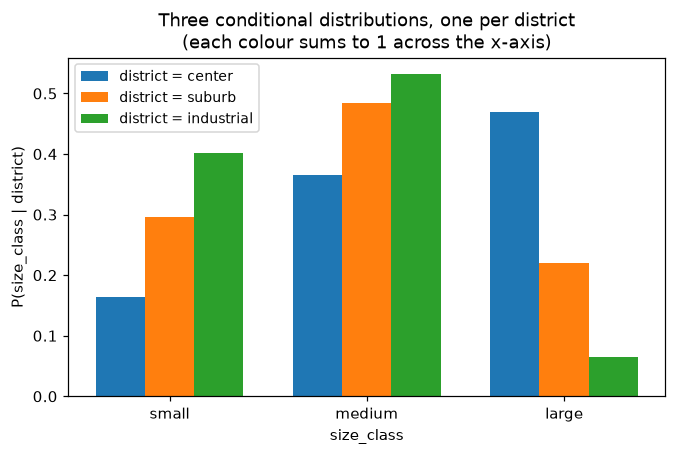

In [59]:
x_positions = np.arange(len(SIZE_CLASSES))         # 0, 1, 2: base positions for the groups
bar_width = 0.25                                   # each of the 3 bars takes a third of the slot

fig, ax = plt.subplots(figsize=(7, 4))

for i, d_value in enumerate(DISTRICTS):
    offset = (i - 1) * bar_width                   # -0.25, 0.0, +0.25 so the bars sit side by side
    ax.bar(x_positions + offset,                   # shifted group positions
           cond_size_given_district[i],            # row i: the conditional distribution
           width=bar_width,
           label=f"district = {d_value}")

ax.set_xticks(x_positions)
ax.set_xticklabels(SIZE_CLASSES)
ax.set_xlabel("size_class")
ax.set_ylabel("P(size_class | district)")
ax.set_title("Three conditional distributions, one per district\n(each colour sums to 1 across the x-axis)")
ax.legend(fontsize=9)
plt.show()

**Line by line**

- `np.arange(3)` gives the base x positions `[0, 1, 2]`, one per size class.
- `offset = (i - 1) * bar_width` : centres the group of three bars on the tick. With `i` running `0, 1, 2`
  the offsets are `-0.25, 0.0, +0.25`.
- `cond_size_given_district[i]` : row `i` of the conditional table, which is one full distribution.
- The important reading: **each colour sums to 1 across the three ticks**, not each tick across the
  colours. If the three colours were identical the variables would be independent, and knowing the
  district would tell you nothing about the size.

### 2d. Independence, and the product rule

Two variables are **independent** exactly when the joint factorises into the product of its marginals:

$$P(A, B) = P(A)\,P(B) \quad \text{for every combination}$$

Equivalently, $P(A \mid B) = P(A)$: conditioning on $B$ tells you nothing new about $A$.

That product-of-marginals table is the **outer product** of the two marginal vectors,
$\mathbf{p}\mathbf{q}^\top$, so the whole test is one `np.outer` call and a comparison. When the two
tables differ, the variables are dependent and the size of the difference is a rough measure of how
much one feature says about the other.

In [60]:
independent_table = np.outer(marg_district, marg_size)    # p q^T: what the joint WOULD be if independent

difference = joint - independent_table                    # cell-by-cell gap between reality and independence

print("if independent, P(district, size) would be:")
print(pd.DataFrame(independent_table, index=DISTRICTS, columns=SIZE_CLASSES).round(3))
print("\nactual joint:")
print(pd.DataFrame(joint, index=DISTRICTS, columns=SIZE_CLASSES).round(3))
print("\ndifference (actual - independent):")
print(pd.DataFrame(difference, index=DISTRICTS, columns=SIZE_CLASSES).round(3))

print("\nlargest absolute deviation:", np.abs(difference).max().round(4))
print("independent?", np.allclose(joint, independent_table, atol=1e-3))
print("\nboth tables still sum to 1:",
      independent_table.sum().round(6), joint.sum().round(6))

if independent, P(district, size) would be:
            small  medium  large
center      0.094   0.153  0.088
suburb      0.111   0.182  0.104
industrial  0.075   0.122  0.070

actual joint:
            small  medium  large
center      0.055   0.122  0.158
suburb      0.118   0.192  0.088
industrial  0.108   0.142  0.018

difference (actual - independent):
            small  medium  large
center     -0.039  -0.031  0.070
suburb      0.006   0.011 -0.017
industrial  0.033   0.020 -0.053

largest absolute deviation: 0.0696
independent? False

both tables still sum to 1: 1.0 1.0


**Line by line**

- `np.outer(p, q)` : builds the matrix whose `[i, j]` entry is `p[i] * q[j]`. Every combination of one
  entry from each vector, multiplied. That is the definition of independence written as an array
  operation.
- `joint - independent_table` : elementwise subtraction, so each cell says how much more (positive) or
  less (negative) likely that combination is than independence predicts.
- `np.allclose(..., atol=1e-3)` : a deliberately generous tolerance. Even truly independent variables
  will not match exactly in a finite sample, so the question is never "are they equal?" but "are they
  close enough given $n$?".

**Reading the differences.** `(center, large)` is about +0.07 above what independence predicts and
`(industrial, large)` about −0.05 below. District and size are **dependent**, which is a good thing: a
feature that is independent of everything you care about is a feature that cannot help you predict
anything.

In [61]:
p_center = marg_district[DISTRICTS.index("center")]              # P(district = center)
p_large_given_center = cond_size_given_district[DISTRICTS.index("center"),
                                                SIZE_CLASSES.index("large")]
p_joint_direct = joint[DISTRICTS.index("center"), SIZE_CLASSES.index("large")]

print(f"P(center)                 = {p_center:.4f}")
print(f"P(large | center)         = {p_large_given_center:.4f}")
print(f"product of the two        = {p_center * p_large_given_center:.4f}")
print(f"P(center, large) directly = {p_joint_direct:.4f}")
print("\nproduct rule holds:", np.isclose(p_center * p_large_given_center, p_joint_direct))

p_large = marg_size[SIZE_CLASSES.index("large")]
print(f"\nP(large) overall          = {p_large:.4f}")
print(f"P(large | center)         = {p_large_given_center:.4f}   <- conditioning moved the belief")

P(center)                 = 0.3350
P(large | center)         = 0.4701
product of the two        = 0.1575
P(center, large) directly = 0.1575

product rule holds: True

P(large) overall          = 0.2625
P(large | center)         = 0.4701   <- conditioning moved the belief


**Line by line**

- `DISTRICTS.index("center")` : looks up the position of a name in the list, so the code reads by name
  instead of by a bare `0` whose meaning has to be remembered.
- The first four prints verify the **product rule** $P(A, B) = P(A \mid B)P(B)$ numerically. It is not an
  approximation or a modelling assumption; it is the rearranged definition of a conditional probability,
  and it holds exactly.
- The last two lines are the sentence Bayes rule is built on: $P(\text{large})$ is about 0.26 overall, but
  among center apartments it is about 0.47. **Evidence moved the belief**, and the machinery for
  quantifying that move is Part 3.

---
## Part 3: Prior probabilities and Bayes rule

### 3a. Where the rule comes from

The product rule from 2d can be written two ways, because $P(A, B)$ and $P(B, A)$ are the same table
read in two directions:

$$P(A, B) = P(A \mid B)\,P(B) \qquad \text{and} \qquad P(A, B) = P(B \mid A)\,P(A)$$

Set them equal and divide by $P(B)$:

$$\boxed{\;P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}\;}$$

That is **Bayes rule**, and it is three lines of algebra away from the definition of a conditional
probability. There is nothing mysterious in the derivation; what is remarkable is what it lets you do.

Rename the symbols for the classification setting, with $C$ a class and $x$ an observed feature:

$$\underbrace{P(C \mid x)}_{\textbf{posterior}} = \frac{\overbrace{P(x \mid C)}^{\textbf{likelihood}} \; \overbrace{P(C)}^{\textbf{prior}}}{\underbrace{P(x)}_{\textbf{evidence}}}$$

| term | name | what it means | where it comes from |
|---|---|---|---|
| $P(C)$ | **prior** | what we believe about the class *before* looking at this apartment | counting labels in the training set |
| $P(x \mid C)$ | **likelihood** | how typical this feature value is *within* each class | the class-conditional distributions of Part 1 |
| $P(x)$ | **evidence** | how likely this feature value is overall | $\sum_c P(x \mid c)P(c)$, the marginal |
| $P(C \mid x)$ | **posterior** | the updated belief *after* seeing the feature | what we actually want |

**The evidence is not an extra input.** By the law of total probability,
$P(x) = \sum_c P(x \mid c)P(c)$ — it is built entirely from the prior and the likelihood, and its only
job is to make the posterior sum to 1 across the classes. It is a normalising constant.

Read the rule as an engineering statement: **it reverses the direction of a conditional.** Our generator
in Part 0 knew $P(x \mid C)$ and we want $P(C \mid x)$. Bayes rule is the only way to turn one into
the other, and it charges a fee for the reversal: you must supply a prior.

### 3b. A worked example before touching the data

Before applying this to apartments, a clean two-hypothesis example where every number is given, so the
arithmetic is visible.

A building surveyor uses a damp-detection test on apartments.

- **Prior**: 5% of apartments in this city have a damp problem. $P(\text{damp}) = 0.05$.
- **Sensitivity**: if an apartment is damp, the test flags it 95% of the time.
  $P(+ \mid \text{damp}) = 0.95$.
- **False positive rate**: if it is dry, the test still flags it 8% of the time.
  $P(+ \mid \text{dry}) = 0.08$.

An apartment tests positive. **What is the probability it actually has damp?**

Most people answer somewhere near 90%. Compute it before running the cell, then compare.

In [62]:
def bayes_posterior(prior, likelihood):
    '''Posterior over hypotheses given a prior vector and a likelihood vector for the observed evidence.

    prior      : (k,) array, P(H_i), must sum to 1
    likelihood : (k,) array, P(evidence | H_i) for the ONE evidence value that was observed
    returns    : (k,) posterior array P(H_i | evidence), sums to 1
    '''
    unnormalised = prior * likelihood              # elementwise: P(e | H_i) P(H_i), the joint P(H_i, e)
    evidence = unnormalised.sum()                  # P(e) = sum over hypotheses: the normaliser
    return unnormalised / evidence                 # divide so the posterior sums to 1


HYPOTHESES = ["damp", "dry"]                       # index 0 = damp, index 1 = dry

prior_damp = np.array([0.05, 0.95])                # P(damp), P(dry): the base rate
lik_positive = np.array([0.95, 0.08])              # P(+ | damp), P(+ | dry): the test's behaviour

posterior_damp = bayes_posterior(prior_damp, lik_positive)

print("prior            P(damp) =", prior_damp[0])
print("likelihood  P(+ | damp)  =", lik_positive[0])
print("likelihood  P(+ | dry)   =", lik_positive[1])
print()
print("unnormalised P(H, +)     =", (prior_damp * lik_positive).round(4))
print("evidence     P(+)        =", (prior_damp * lik_positive).sum().round(4))
print()
print("POSTERIOR   P(damp | +)  =", posterior_damp[0].round(4))
print("POSTERIOR   P(dry  | +)  =", posterior_damp[1].round(4))
print("posterior sums to 1      :", posterior_damp.sum().round(10))

prior            P(damp) = 0.05
likelihood  P(+ | damp)  = 0.95
likelihood  P(+ | dry)   = 0.08

unnormalised P(H, +)     = [0.048 0.076]
evidence     P(+)        = 0.1235

POSTERIOR   P(damp | +)  = 0.3846
POSTERIOR   P(dry  | +)  = 0.6154
posterior sums to 1      : 1.0


**Line by line**

- `prior * likelihood` : a single `*`, elementwise, **not** `@`. Each hypothesis is scored independently:
  entry `i` is $P(e \mid H_i)P(H_i)$, which by the product rule is the joint $P(H_i, e)$. There is
  nothing to sum across hypotheses at this stage, which is exactly why `@` would be wrong.
- `unnormalised.sum()` : adding the joint across all hypotheses marginalises $H$ away and leaves
  $P(e)$. **The evidence is computed, never supplied**, and it is the marginalisation operation from 2b
  doing its job.
- `unnormalised / evidence` : one division that forces the result to sum to 1.
- The function takes the likelihood **for the evidence that was actually observed**. Had the test come
  back negative we would pass `[0.05, 0.92]` instead, which is $1 - 0.95$ and $1 - 0.08$.

**The answer is about 0.38, not 0.90.** A "95% accurate" test produces an apartment that is more likely
dry than damp. The reason is the prior: dry apartments outnumber damp ones 19 to 1, so the small 8%
false-positive rate applied to a large group produces more false alarms (0.076) than the 95% detection
rate applied to a small group produces true ones (0.0475).

Ignoring the base rate and reading $P(+ \mid \text{damp}) = 0.95$ as if it were
$P(\text{damp} \mid +)$ is the **base-rate fallacy**, and it is the single most common probability
error in applied work. Bayes rule is the correction.

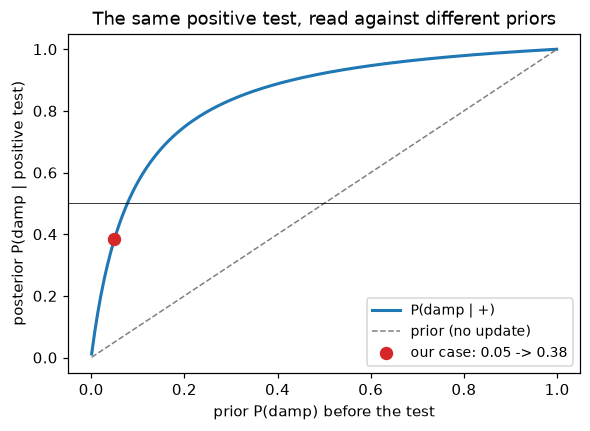

the posterior only exceeds 0.5 once the prior exceeds about 0.078


In [63]:
prior_grid = np.linspace(0.001, 0.999, 300)        # 300 candidate base rates from ~0 to ~1

posteriors = []                                    # collect one posterior per candidate prior
for p in prior_grid:                               # p = P(damp) under this hypothetical base rate
    prior_vector = np.array([p, 1.0 - p])          # the two-outcome prior must sum to 1
    posteriors.append(bayes_posterior(prior_vector, lik_positive)[0])   # keep P(damp | +)

posteriors = np.array(posteriors)                  # list -> array, so it can be plotted and indexed

fig, ax = plt.subplots()

ax.plot(prior_grid, posteriors, color="tab:blue", lw=2, label="P(damp | +)")
ax.plot(prior_grid, prior_grid, "--", color="grey", lw=1, label="prior (no update)")
ax.scatter([0.05], [posterior_damp[0]], color="tab:red", zorder=3, s=60,
           label=f"our case: 0.05 -> {posterior_damp[0]:.2f}")
ax.axhline(0.5, color="black", lw=0.5)

ax.set_xlabel("prior P(damp) before the test")
ax.set_ylabel("posterior P(damp | positive test)")
ax.set_title("The same positive test, read against different priors")
ax.legend(fontsize=9)
plt.show()

crossing = prior_grid[np.argmin(np.abs(posteriors - 0.5))]     # where the posterior first passes 0.5
print(f"the posterior only exceeds 0.5 once the prior exceeds about {crossing:.3f}")

**Line by line**

- `np.linspace(0.001, 0.999, 300)` : stops just short of 0 and 1 because a prior of exactly 0 makes a
  hypothesis unfalsifiable: multiplying by zero keeps the posterior at zero no matter how strong the
  evidence. **Never assign a prior of exactly zero to something you are willing to be convinced of.**
- The loop rebuilds a full two-entry prior for each candidate `p`, because `bayes_posterior` expects a
  distribution, not a single number.
- `[0]` at the end of the `bayes_posterior` call keeps only $P(\text{damp} \mid +)$, since the other
  entry is one minus it.
- `ax.plot(prior_grid, prior_grid, "--")` : the identity line, showing where the posterior would sit if
  the test told us nothing. **The vertical gap between the blue curve and the dashed line is exactly how
  much this test is worth.**
- `np.argmin(np.abs(posteriors - 0.5))` : the index whose posterior is closest to 0.5, i.e. where the
  decision flips. A useful idiom: `argmin` of an absolute difference is "find the nearest".

**Reading it.** The blue curve is above the dashed line everywhere, so a positive result always increases
belief in damp; the test is informative. But it takes a prior above roughly 0.08 before the evidence is
strong enough to make damp the *more likely* explanation. The same evidence, the same likelihoods, and a
different conclusion, purely because of the prior.

In [64]:
lik_positive_second = np.array([0.95, 0.08])       # a second, independent test with the same reliability

posterior_after_1 = bayes_posterior(prior_damp, lik_positive)          # after the first positive
posterior_after_2 = bayes_posterior(posterior_after_1, lik_positive_second)   # yesterday's posterior is today's prior

lik_negative = 1.0 - lik_positive                  # P(- | damp) = 0.05, P(- | dry) = 0.92
posterior_pos_then_neg = bayes_posterior(posterior_after_1, lik_negative)

print(f"start          P(damp)        = {prior_damp[0]:.4f}")
print(f"after 1 positive              = {posterior_after_1[0]:.4f}")
print(f"after 2 positives             = {posterior_after_2[0]:.4f}")
print(f"after positive then negative  = {posterior_pos_then_neg[0]:.4f}")

both_at_once = bayes_posterior(prior_damp, lik_positive * lik_positive_second)
print(f"\nboth positives handled in one step = {both_at_once[0]:.4f}")
print("sequential and batch updating agree:", np.isclose(both_at_once[0], posterior_after_2[0]))

start          P(damp)        = 0.0500
after 1 positive              = 0.3846
after 2 positives             = 0.8813
after positive then negative  = 0.0329

both positives handled in one step = 0.8813
sequential and batch updating agree: True


**Line by line**

- `bayes_posterior(posterior_after_1, lik_positive_second)` : the whole idea of **sequential updating**:
  the posterior after the first observation is passed in as the prior for the second. Belief accumulates;
  nothing needs to be recomputed from scratch.
- `lik_negative = 1.0 - lik_positive` : since the test has exactly two outcomes, the probability of a
  negative result is one minus the probability of a positive one, computed per hypothesis.
- The third result is the interesting one: a positive followed by a negative lands *below* the starting
  posterior. **Evidence can move belief in either direction**, and the machinery handles both without any
  special case.
- `lik_positive * lik_positive_second` : multiplying the likelihoods and updating once gives the same
  answer as two sequential updates. That is only valid because the tests are assumed **conditionally
  independent given the true state**. Hold onto this: it is exactly the assumption the naive Bayes
  classifier makes in Part 4, applied to features instead of tests.

### 3c. Bayes rule on the actual dataset

Now the real thing. We want $P(\text{expensive} \mid \text{district})$, but the *generator* in Part 0 was
written the other way around — it drew the district **given** the class. So this is exactly the reversal
Bayes rule performs:

$$P(C = 1 \mid \text{district} = u) = \frac{P(\text{district} = u \mid C = 1)\,P(C = 1)}{\sum_{c} P(\text{district} = u \mid C = c)\,P(C = c)}$$

Because both variables are discrete we can compute the answer **two independent ways** — straight from
the joint table, and through Bayes rule from the prior and likelihood — and check they agree. If Bayes
rule is really just rearranged bookkeeping, they must.

In [65]:
joint_dc_counts = np.zeros((2, len(DISTRICTS)))    # rows = class (0, 1), columns = district

for c in (0, 1):
    for j, d_value in enumerate(DISTRICTS):
        joint_dc_counts[c, j] = np.sum((df["expensive"] == c) & (df["district"] == d_value))

joint_dc = joint_dc_counts / joint_dc_counts.sum()             # joint P(class, district), sums to 1

prior_class = joint_dc.sum(axis=1)                             # marginalise district away: P(class)
marg_district_2 = joint_dc.sum(axis=0)                         # marginalise class away:    P(district)

likelihood_d_given_c = joint_dc / prior_class[:, None]         # P(district | class): rows sum to 1

print("joint P(class, district):")
print(pd.DataFrame(joint_dc, index=CLASS_NAMES, columns=DISTRICTS).round(3))
print("\nprior P(class)      :", prior_class.round(3), " (true value used by the generator:", TRUE_PRIOR, ")")
print("marginal P(district):", marg_district_2.round(3))
print("\nlikelihood P(district | class):")
print(pd.DataFrame(likelihood_d_given_c, index=CLASS_NAMES, columns=DISTRICTS).round(3))
print("\ntrue likelihood used by the generator:")
print(pd.DataFrame(np.vstack([TRUE_P_DISTRICT[0], TRUE_P_DISTRICT[1]]),
                   index=CLASS_NAMES, columns=DISTRICTS).round(3))

joint P(class, district):
            center  suburb  industrial
affordable   0.108   0.288       0.245
expensive    0.228   0.110       0.022

prior P(class)      : [0.64 0.36]  (true value used by the generator: [0.65 0.35] )
marginal P(district): [0.335 0.397 0.268]

likelihood P(district | class):
            center  suburb  industrial
affordable   0.168   0.449       0.383
expensive    0.632   0.306       0.062

true likelihood used by the generator:
            center  suburb  industrial
affordable    0.15    0.45         0.4
expensive     0.60    0.30         0.1


**Line by line**

- The double loop is the same joint-counting pattern as 2a, now over `(class, district)` instead of
  `(district, size)`.
- `joint_dc.sum(axis=1)` : summing away the district leaves `P(class)`, which **is** the prior. Notice
  what just happened: the prior is not an extra assumption smuggled in from outside, it is a marginal of
  the joint, estimated by counting labels.
- `joint_dc.sum(axis=0)` : summing away the class leaves `P(district)`, the evidence term.
- `joint_dc / prior_class[:, None]` : dividing each **row** by its class total gives
  $P(\text{district} \mid \text{class})$, the likelihood. Same `[:, None]` column-vector trick as 2c; the
  orientation is what decides whether you get $P(d \mid c)$ or $P(c \mid d)$.
- The comparison against `TRUE_P_DISTRICT` closes the loop on Part 0: counting 400 samples recovers the
  generator's numbers to within a few hundredths, the largest error being on `P(industrial | expensive)`,
  where the true 0.10 is estimated as 0.06. That is the cell with the fewest observations behind it, and
  it is no accident: **the least-supported probability is the least accurate one.** Estimation works, and
  finite samples are approximate. Both halves of that sentence matter.

In [66]:
def posterior_given_district(d_value):
    '''Full posterior over the two classes, given one observed district, via Bayes rule.'''
    j = DISTRICTS.index(d_value)                       # which column of the likelihood table to use
    lik = likelihood_d_given_c[:, j]                   # P(district = d_value | C=0), P(... | C=1)
    return bayes_posterior(prior_class, lik)           # reuse the same function as the damp example


rows = []
for d_value in DISTRICTS:
    post = posterior_given_district(d_value)                       # via Bayes rule
    direct = joint_dc[:, DISTRICTS.index(d_value)] / marg_district_2[DISTRICTS.index(d_value)]
    rows.append({
        "district": d_value,
        "prior P(expensive)": prior_class[1],
        "P(district | expensive)": likelihood_d_given_c[1, DISTRICTS.index(d_value)],
        "evidence P(district)": marg_district_2[DISTRICTS.index(d_value)],
        "posterior via Bayes": post[1],
        "posterior direct": direct[1],
    })

result = pd.DataFrame(rows).set_index("district")
print(result.round(4))
print("\nthe two posterior columns agree:",
      np.allclose(result["posterior via Bayes"], result["posterior direct"]))

            prior P(expensive)  P(district | expensive)  evidence P(district)  \
district                                                                        
center                    0.36                    0.632                 0.335   
suburb                    0.36                    0.306                 0.398   
industrial                0.36                    0.062                 0.268   

            posterior via Bayes  posterior direct  
district                                           
center                    0.679             0.679  
suburb                    0.277             0.277  
industrial                0.084             0.084  

the two posterior columns agree: True


**Line by line**

- `likelihood_d_given_c[:, j]` : a **column** of the likelihood table: the probability of this one
  observed district under each class. That is the vector `bayes_posterior` expects, and slicing a column
  is what "condition on the evidence we actually saw" looks like in code.
- `joint_dc[:, j] / marg_district_2[j]` : the direct route: take the joint column for this district and
  divide by its total. No Bayes rule involved, just the definition of a conditional from 2c.
- The two columns match to machine precision, which is the point of the cell. **Bayes rule is not a new
  fact about the world**; it is a way of computing a conditional when the numbers you happen to have are
  facing the other direction. Here we could go either way. In Part 4 the features are continuous and the
  direct route is unavailable, which is when the rule earns its keep.

**Reading the numbers.** Prior belief that an apartment is expensive: about 0.36. Learning it is in the
center pushes that to about 0.68; learning it is industrial collapses it to about 0.08. One feature, one
observation, and belief moves by a factor of roughly eight between the two extremes.

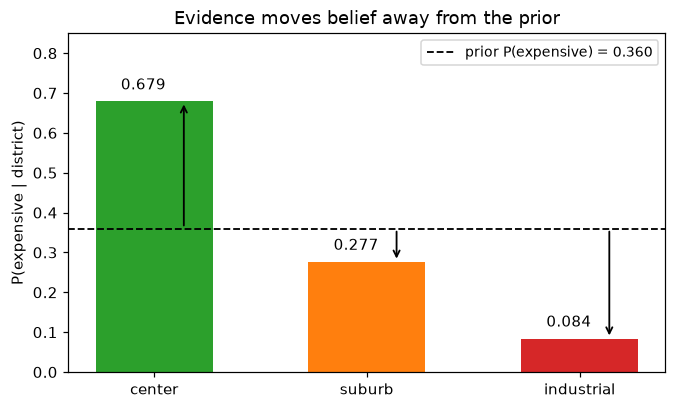

In [67]:
fig, ax = plt.subplots(figsize=(7, 4))

x_pos = np.arange(len(DISTRICTS))
posterior_values = np.array([posterior_given_district(d)[1] for d in DISTRICTS])

ax.bar(x_pos, posterior_values, color=["tab:green", "tab:orange", "tab:red"], width=0.55)
ax.axhline(prior_class[1], ls="--", color="black", lw=1.2,
           label=f"prior P(expensive) = {prior_class[1]:.3f}")

for x, p in zip(x_pos, posterior_values):
    ax.annotate("", xy=(x + 0.14, p), xytext=(x + 0.14, prior_class[1]),   # arrow: prior level -> posterior
                arrowprops=dict(arrowstyle="->", color="black", lw=1.2))
    ax.text(x - 0.05, p + 0.03, f"{p:.3f}", ha="center", fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels(DISTRICTS)
ax.set_ylabel("P(expensive | district)")
ax.set_ylim(0, 0.85)
ax.set_title("Evidence moves belief away from the prior")
ax.legend(fontsize=9)
plt.show()

**Line by line**

- The list comprehension calls `posterior_given_district` once per district and keeps entry `[1]`, the
  probability of the expensive class.
- `color=[...]` : a list of three colours, one per bar, rather than one colour for all of them.
- `ax.annotate("", xy=..., xytext=...)` — an empty string with `arrowprops` draws a bare arrow: from
  `xytext` (the prior line) to `xy` (the posterior bar top). Passing text here would print it at the tip.
  The small `+ 0.14` and `- 0.05` offsets shift the arrow and the number apart so they do not overlap;
  both still sit inside their bar, which is 0.55 wide.
- `ax.set_ylim(0, 0.85)` : headroom again, so the `+0.03` text offsets stay inside the figure.

**Reading it.** The dashed line is what you would believe knowing nothing about a particular apartment.
Each arrow is one piece of evidence doing its work. A classifier is nothing more than this picture
extended to several features at once, which is Part 4.

---
## Part 4 : A maximum-a-posteriori (MAP) classifier

### 4a. The decision rule

Part 3 produced a full posterior distribution over classes. To *classify* we must commit to one answer,
and the natural choice is the class with the largest posterior probability:

$$\hat{c}(x) \;=\; \arg\max_{c} \; P(C = c \mid x) \;=\; \arg\max_{c} \; \frac{P(x \mid c)P(c)}{P(x)} \;=\; \arg\max_{c} \; P(x \mid c)\,P(c)$$

**The evidence $P(x)$ disappears from the argmax.** It is the same positive number for every class, so
dividing by it cannot change which class is largest. Never compute it unless you want calibrated
probabilities to report — for the decision itself, prior times likelihood is enough.

This is the **maximum a posteriori** rule. Its close relative, **maximum likelihood**, drops the prior
too and takes $\arg\max_c P(x \mid c)$. Section 4d shows exactly when and why that changes answers.

Our feature vector has three components:

$$x = (\text{area\_m2}, \; \text{age\_yrs}, \; \text{district})$$

so the likelihood we need is the joint $P(\text{area}, \text{age}, \text{district} \mid c)$ — a
three-dimensional object over a mix of continuous and discrete variables. Estimating that directly from
300 training rows is hopeless. The standard escape is one assumption.

**The naive Bayes assumption.** Given the class, the features are conditionally independent:

$$P(x_1, x_2, x_3 \mid c) \;=\; P(x_1 \mid c)\,P(x_2 \mid c)\,P(x_3 \mid c)$$

One hard three-dimensional density becomes three easy one-dimensional ones. This is the same
factorisation that let two damp tests be combined by multiplying their likelihoods in 3b.

It is called *naive* because it is usually false — larger apartments genuinely do sit in different
districts, so area and district are not independent even within a class. The assumption survives because
the argmax often lands on the right class even when the probabilities themselves are poorly calibrated.

In [68]:
n_train = 300                                      # how many of the 400 rows to train on
perm = rng.permutation(len(df))                    # a random ordering of all row indices

train_idx = perm[:n_train]                         # first 300 shuffled indices -> training set
test_idx = perm[n_train:]                          # remaining 100              -> test set

train = df.iloc[train_idx].reset_index(drop=True)  # .iloc selects rows by integer position
test = df.iloc[test_idx].reset_index(drop=True)

y_train = train["expensive"].to_numpy()            # (300,) labels: 0 or 1
y_test = test["expensive"].to_numpy()              # (100,)

CONT_FEATURES = ["area_m2", "age_yrs"]             # the two continuous features
Xc_train = train[CONT_FEATURES].to_numpy()         # (300, 2) continuous design matrix
Xc_test = test[CONT_FEATURES].to_numpy()           # (100, 2)

d_train = train["district"].to_numpy()             # (300,) categorical feature as strings
d_test = test["district"].to_numpy()               # (100,)

print("train shape:", Xc_train.shape, " test shape:", Xc_test.shape)
print("class balance in train:", np.bincount(y_train) / len(y_train))
print("class balance in test :", np.bincount(y_test) / len(y_test))
print("no overlap between the two sets:", len(set(train_idx) & set(test_idx)) == 0)

train shape: (300, 2)  test shape: (100, 2)
class balance in train: [0.637 0.363]
class balance in test : [0.65 0.35]
no overlap between the two sets: True


**Line by line**

- `rng.permutation(len(df))` : a random shuffle of the integers `0 .. 399`. Slicing that shuffled array
  is the simplest correct way to split data. Taking the *first* 300 rows without shuffling would be a bug
  whenever the file has any ordering to it.
- `df.iloc[train_idx]` : `.iloc` selects by integer **position**, `.loc` selects by index **label**. After
  a shuffle these differ, and `.iloc` is what we want.
- `.reset_index(drop=True)` : renumbers the rows `0, 1, 2, ...` and throws away the old scrambled index,
  so later positional indexing into `train` is not confusing. Without `drop=True` the old index is kept
  as a new column.
- `.to_numpy()` : pandas out, NumPy in. Every calculation from here uses arrays, matching the previous
  practical's convention that a dataset is a matrix.
- `np.bincount(y_train)` : counts occurrences of each non-negative integer, so entry `0` is the number of
  zeros. Dividing by the length gives the class proportions, and they should look similar in both splits.
- **Why split at all?** The classifier will be *fitted* on the training rows only; the test rows are held
  back and used once, to estimate how it behaves on data it has never seen. The previous practical
  measured its accuracy on the same rows it fitted and got a flattering, meaningless number. This one
  will not.

### 4b. Estimating the prior

$$\hat{P}(C = c) = \frac{\text{number of training rows with label } c}{\text{number of training rows}}$$

Counting the labels, exactly as in Part 1a. This is the **only** place the prior comes from in this
notebook; if the training data is not representative of where the classifier will be used, the prior is
wrong and every posterior inherits that error.

In [69]:
class_counts = np.array([np.sum(y_train == c) for c in (0, 1)], dtype=float)
prior_hat = class_counts / class_counts.sum()      # count and divide: the estimated prior

print("training label counts:", class_counts)
print("estimated prior      :", prior_hat.round(4))
print("true prior           :", TRUE_PRIOR)
print("sums to 1            :", prior_hat.sum())

log_prior = np.log(prior_hat)                      # stored in logs, for reasons explained in 4c
print("\nlog prior            :", log_prior.round(4))

training label counts: [191. 109.]
estimated prior      : [0.637 0.363]
true prior           : [0.65 0.35]
sums to 1            : 1.0

log prior            : [-0.452 -1.012]


**Line by line**

- `np.sum(y_train == c)` : the counting-a-boolean-array pattern for the third time. It is worth
  recognising instantly.
- `dtype=float` again, so the division is not integer division and so `np.log` behaves predictably.
- `np.log(prior_hat)` : the natural logarithm, elementwise. Because both entries are below 1, both logs
  are negative. Storing them now saves recomputing inside the prediction loop.

### 4c. Estimating the likelihoods

Two feature types, two estimation methods, both already introduced in Part 1.

**Discrete (`district`)** : count the district values *within each class* and divide by that class's
total. This is the same $P(\text{district} \mid C)$ table computed in 3c, now on the training split only:

$$\hat{P}(\text{district} = u \mid C = c) = \frac{\text{count}(u, c) + \alpha}{\text{count}(c) + \alpha K}$$

The $\alpha$ is **Laplace smoothing** and it fixes a specific failure. If no training apartment in class
`expensive` happened to be `industrial`, the count is 0, the estimated probability is 0, and the whole
product $\prod_j P(x_j \mid c)$ collapses to zero forever, a single unseen combination permanently
vetoes a class, no matter what the other features say. Adding $\alpha = 1$ pretends we saw one of each,
which keeps every probability strictly positive.

**Continuous (`area_m2`, `age_yrs`)**: fit one Gaussian per feature **per class**, using the mean and
standard deviation of that class's training rows. Compare this with Part 1c, where a single Gaussian was
fitted to the whole column and visibly failed to capture the two humps: those humps were the classes.

In [70]:
ALPHA = 1.0                                        # Laplace smoothing strength: pretend we saw 1 of each

district_counts = np.zeros((2, len(DISTRICTS)))    # rows = class, columns = district
for c in (0, 1):
    for j, d_value in enumerate(DISTRICTS):
        district_counts[c, j] = np.sum((y_train == c) & (d_train == d_value))

lik_district = (district_counts + ALPHA) / (
    district_counts.sum(axis=1, keepdims=True) + ALPHA * len(DISTRICTS)
)

log_lik_district = np.log(lik_district)            # again, keep the log form ready

print("raw counts per class and district:")
print(pd.DataFrame(district_counts, index=CLASS_NAMES, columns=DISTRICTS))
print("\nsmoothed P(district | class):")
print(pd.DataFrame(lik_district, index=CLASS_NAMES, columns=DISTRICTS).round(3))
print("\neach row sums to 1:", lik_district.sum(axis=1).round(6))

unsmoothed = district_counts / district_counts.sum(axis=1, keepdims=True)
print("\nlargest change caused by smoothing:",
      np.abs(lik_district - unsmoothed).max().round(4))

raw counts per class and district:
            center  suburb  industrial
affordable    34.0    89.0        68.0
expensive     70.0    34.0         5.0

smoothed P(district | class):
            center  suburb  industrial
affordable   0.180   0.464       0.356
expensive    0.634   0.312       0.054

each row sums to 1: [1. 1.]

largest change caused by smoothing: 0.0083


**Line by line**

- `(y_train == c) & (d_train == d_value)` : the joint count again, now restricted to training rows.
- `district_counts.sum(axis=1, keepdims=True)` : row totals, i.e. how many training rows are in each
  class. **`keepdims=True` is what makes the division work**: it returns shape `(2, 1)` instead of `(2,)`,
  a column vector that broadcasts across the row. It is the same job `[:, None]` did in Part 2c, spelled
  differently.
- `+ ALPHA` on top and `+ ALPHA * len(DISTRICTS)` on the bottom — the smoothing must be added to the
  denominator as many times as it was added to the numerator, once per category, or the row would no
  longer sum to 1. The printed row sums confirm it does.
- The final comparison shows smoothing shifts these numbers by under a hundredth here, because every
  cell already has plenty of counts behind it. Its value is insurance: it costs almost nothing when data
  is plentiful and prevents a catastrophic zero when it is not. Note where the largest shift lands : on
  `P(industrial | expensive)`, the cell with only five observations, which is exactly the cell most at
  risk of being zero in a smaller sample.

In [71]:
means = np.zeros((2, len(CONT_FEATURES)))          # means[c, j] = mean of feature j within class c
stds = np.zeros((2, len(CONT_FEATURES)))           # stds[c, j]  = std  of feature j within class c

for c in (0, 1):
    rows_of_class = Xc_train[y_train == c]         # (n_c, 2): only the rows belonging to class c
    means[c] = rows_of_class.mean(axis=0)          # column means -> one per feature
    stds[c] = rows_of_class.std(axis=0, ddof=0)    # ddof=0 for the maximum-likelihood estimate

print("P(feature | class) Gaussian parameters\n")
print("means:")
print(pd.DataFrame(means, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))
print("\nstandard deviations:")
print(pd.DataFrame(stds, index=CLASS_NAMES, columns=CONT_FEATURES).round(2))

print("\ntrue generator parameters:")
print(pd.DataFrame([[TRUE_AREA[0][0], TRUE_AGE[0][0]], [TRUE_AREA[1][0], TRUE_AGE[1][0]]],
                   index=CLASS_NAMES, columns=CONT_FEATURES), "  <- true means")

P(feature | class) Gaussian parameters

means:
            area_m2  age_yrs
affordable    63.06    22.22
expensive    106.28     8.08

standard deviations:
            area_m2  age_yrs
affordable    16.08    11.89
expensive     22.42     5.92

true generator parameters:
            area_m2  age_yrs
affordable     65.0     22.0
expensive     105.0      8.0   <- true means


**Line by line**

- `Xc_train[y_train == c]` : **boolean row selection**. The mask has one entry per row, so this keeps
  every column but only the rows of class `c`. The result is a smaller matrix, and everything downstream
  is the same code applied to it.
- `.mean(axis=0)` and `.std(axis=0)` — `axis=0` collapses the row dimension, leaving one number per
  **column**, i.e. per feature. Same axis convention as the marginals in Part 2b, and the same convention
  the previous practical used to standardise features.
- `ddof=0` : the maximum-likelihood standard deviation, matching the formula in Part 1c.
- The estimated means sit close to the generator's true values, and the two classes are clearly
  separated on both features: about 63 versus 106 m², about 22 versus 8 years. **That separation is the
  entire reason classification is possible.** Two classes with identical class-conditional distributions
  would be indistinguishable no matter how clever the classifier.

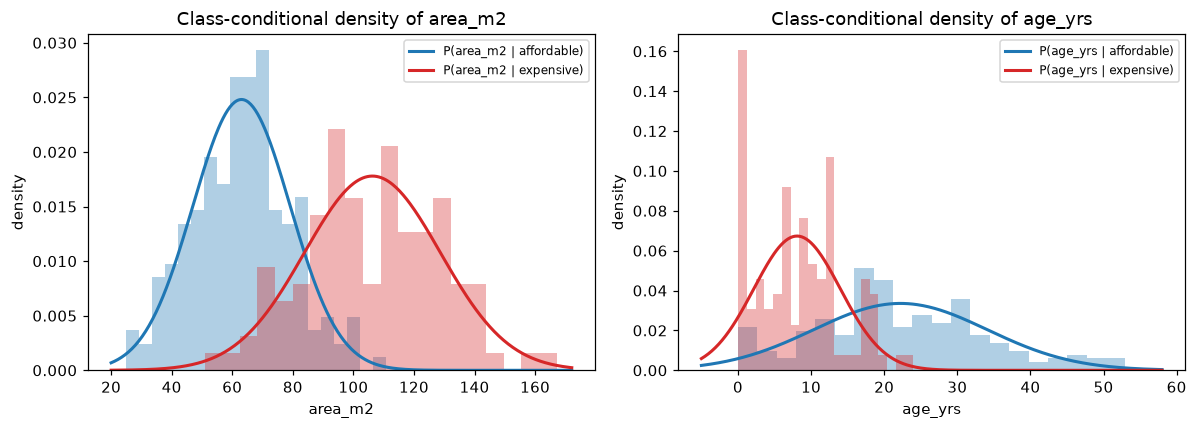

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for j, feature in enumerate(CONT_FEATURES):
    ax = axes[j]
    x_grid = np.linspace(Xc_train[:, j].min() - 5, Xc_train[:, j].max() + 5, 400)

    for c, color in zip((0, 1), ("tab:blue", "tab:red")):
        values_c = Xc_train[y_train == c, j]                       # this class's values for this feature
        ax.hist(values_c, bins=20, density=True, alpha=0.35, color=color)
        ax.plot(x_grid, gaussian_pdf(x_grid, means[c, j], stds[c, j]),
                color=color, lw=2, label=f"P({feature} | {CLASS_NAMES[c]})")

    ax.set_xlabel(feature)
    ax.set_ylabel("density")
    ax.set_title(f"Class-conditional density of {feature}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Line by line**

- The outer loop runs once per feature and takes `axes[j]`, so each feature gets its own panel.
- `Xc_train[y_train == c, j]` : a **two-part index**: rows selected by the boolean mask, column selected
  by `j`. One expression that filters both dimensions at once.
- `zip((0, 1), ("tab:blue", "tab:red"))` : pairs each class with its colour so the loop stays short.
- `density=True` on the histograms puts the bars on the same scale as the fitted curves, exactly as in
  Part 1c.

**Reading the panels.** Each panel shows two curves that overlap in the middle. Where they overlap the
classifier cannot be certain : an 85 m² apartment is plausible under both classes. Where they separate,
the evidence is decisive. **The overlap region is where classification errors live**, and no amount of
tuning removes it; it is a property of the data, not of the method.

Compare this with the single fitted Gaussian in Part 1c. That right-skewed histogram was these two
curves added together, weighted by the prior. A mixture, seen without its labels.

**One visible imperfection, worth not glossing over.** The red histogram in the age panel has a spike at
exactly 0. That is the `np.clip(age, 0, None)` from Part 0: the expensive class was generated with mean
8 and standard deviation 6, so a handful of draws went negative and were clamped to zero, piling up
there. A Gaussian cannot produce a spike, so the fitted red curve simply spreads that mass around and
even assigns density to negative ages, which are impossible. The model is an approximation to the data,
never a description of it, and noticing where it is wrong is part of using it responsibly.

#### Aside : why every probability is about to become a logarithm

The MAP score is a product of a prior and several likelihoods:

$$\text{score}(c) = P(c) \prod_{j} P(x_j \mid c)$$

For 3 features those numbers are small; for 300 features (a document classified by its words, say) the
product is around $10^{-400}$, which is **zero** in 64-bit floating point. The classifier would then
compare zero against zero and pick a class arbitrarily. This is called numerical **underflow** and it is
not a rare edge case.

The fix is to work with the logarithm. Because $\log$ is strictly increasing, whichever class has the
largest score also has the largest log-score, so the argmax is unchanged:

$$\log \text{score}(c) = \log P(c) + \sum_j \log P(x_j \mid c)$$

Products become sums, tiny numbers become moderate negative ones, and underflow disappears. **Any
serious implementation of a probabilistic classifier works in log space** — this is a rule, not a
preference.

To recover actual probabilities at the end, subtract the largest log-score before exponentiating:

$$P(c \mid x) = \frac{\exp(\ell_c - \max_k \ell_k)}{\sum_{c'} \exp(\ell_{c'} - \max_k \ell_k)}$$

Subtracting the max makes the largest exponent exactly $0$, so `np.exp` never overflows, and the constant
cancels top and bottom leaving the ratio untouched. This is the **log-sum-exp** trick.

In [73]:
def log_gaussian_pdf(x, mu, sigma):
    '''log of the Gaussian density: the same formula as gaussian_pdf, with the log taken analytically.'''
    return -0.5 * np.log(2.0 * np.pi * sigma ** 2) - ((x - mu) ** 2) / (2.0 * sigma ** 2)


check_x = np.array([50.0, 90.0, 130.0])            # three test values to verify the two forms agree
print("log(gaussian_pdf) :", np.log(gaussian_pdf(check_x, 100.0, 20.0)).round(6))
print("log_gaussian_pdf  :", log_gaussian_pdf(check_x, 100.0, 20.0).round(6))
print("identical:", np.allclose(np.log(gaussian_pdf(check_x, 100.0, 20.0)),
                                log_gaussian_pdf(check_x, 100.0, 20.0)))

tiny = gaussian_pdf(np.array([400.0]), 100.0, 20.0)               # a value 15 sigma from the mean
print("\ndensity 15 sigma out, computed directly:", tiny)
print("the same thing in log space            :", log_gaussian_pdf(np.array([400.0]), 100.0, 20.0))

log(gaussian_pdf) : [-7.04 -4.04 -5.04]
log_gaussian_pdf  : [-7.04 -4.04 -5.04]
identical: True

density 15 sigma out, computed directly: [0.]
the same thing in log space            : [-116.415]


**Line by line**

- The log is taken **analytically**, not by calling `np.log` on the density. Taking the log of the
  formula turns the `exp` into nothing and the leading fraction into a subtraction, so no small number is
  ever formed in the first place. Writing `np.log(gaussian_pdf(...))` would compute the underflowing
  quantity and *then* try to rescue it, which is too late.
- The equality check confirms the two are the same function on values where both are computable.
- The final pair makes the danger concrete: a point 15 standard deviations from the mean has a density
  that rounds to `0.0` in float64. `log_gaussian_pdf` returns about `-115`, a perfectly ordinary number
  that carries on working. This is precisely the case where the direct version silently destroys
  information.

In [74]:
def joint_log_score(Xc, d_values):
    '''Un-normalised log posterior for every row and every class.

    Xc       : (n, 2) continuous features
    d_values : (n,)   district strings
    returns  : (n, 2) array, entry [i, c] = log P(c) + sum_j log P(x_ij | c)
    '''
    n_rows = Xc.shape[0]                                     # how many samples we are scoring
    scores = np.zeros((n_rows, 2))                           # one score per sample per class

    district_index = np.array([DISTRICTS.index(v) for v in d_values])   # strings -> column positions

    for c in (0, 1):                                         # build each class's score separately
        total = np.full(n_rows, log_prior[c])                # start from log P(c): the prior term
        for j in range(len(CONT_FEATURES)):                  # add one continuous feature at a time
            total = total + log_gaussian_pdf(Xc[:, j], means[c, j], stds[c, j])
        total = total + log_lik_district[c][district_index]  # add the discrete feature's log likelihood
        scores[:, c] = total                                 # store this class's column

    return scores


def log_scores_to_posterior(scores):
    '''Turn un-normalised log scores into a proper posterior, using the log-sum-exp trick.'''
    shifted = scores - scores.max(axis=1, keepdims=True)     # largest entry per row becomes 0
    unnormalised = np.exp(shifted)                           # safe: no exponent is ever positive
    return unnormalised / unnormalised.sum(axis=1, keepdims=True)   # rows now sum to 1


scores_test = joint_log_score(Xc_test, d_test)               # (100, 2) log scores
posterior_test = log_scores_to_posterior(scores_test)        # (100, 2) proper probabilities
pred_test = scores_test.argmax(axis=1)                       # the MAP decision, one per row

print("scores shape:", scores_test.shape, " posterior shape:", posterior_test.shape)
print("\nfirst 5 rows:")
print(pd.DataFrame({
    "log score C=0": scores_test[:5, 0].round(2),
    "log score C=1": scores_test[:5, 1].round(2),
    "P(affordable|x)": posterior_test[:5, 0].round(3),
    "P(expensive|x)": posterior_test[:5, 1].round(3),
    "prediction": [CLASS_NAMES[k] for k in pred_test[:5]],
    "truth": [CLASS_NAMES[k] for k in y_test[:5]],
}))
print("\nevery posterior row sums to 1:", np.allclose(posterior_test.sum(axis=1), 1.0))

scores shape: (100, 2)  posterior shape: (100, 2)

first 5 rows:
   log score C=0  log score C=1  P(affordable|x)  P(expensive|x)  prediction  \
0          -9.45          -9.60            0.535           0.465  affordable   
1          -9.08         -16.03            0.999           0.001  affordable   
2         -19.43          -9.00            0.000           1.000   expensive   
3          -8.62         -14.08            0.996           0.004  affordable   
4          -8.82         -15.18            0.998           0.002  affordable   

        truth  
0  affordable  
1  affordable  
2   expensive  
3  affordable  
4  affordable  

every posterior row sums to 1: True


**Line by line**

- `np.full(n_rows, log_prior[c])` : an array of length `n_rows` filled with the same log prior. Every
  sample starts from the same baseline belief, and the features move it from there. This is the code
  version of the dashed prior line in the Part 3 plot.
- `total = total + log_gaussian_pdf(...)` : **addition, because we are in log space.** In probability
  space this line would be a multiplication, and it is the naive Bayes factorisation
  $\prod_j P(x_j \mid c)$ being applied one feature at a time.
- `log_lik_district[c][district_index]` : **fancy indexing**. `log_lik_district[c]` is a 3-vector of log
  probabilities, and indexing it with an array of 100 positions returns 100 values in one go, no loop.
  This is the discrete analogue of evaluating a density.
- `scores[:, c] = total` : writes the finished column. The result matrix is `(n, 2)`: one row per
  apartment, one column per class.
- `scores.max(axis=1, keepdims=True)` : the largest log score per row, kept as a `(n, 1)` column so it
  broadcasts. After subtracting it, the biggest entry in each row is exactly `0` and `np.exp` is
  guaranteed safe.
- `unnormalised / unnormalised.sum(axis=1, keepdims=True)` : row-wise normalisation. **This division is
  the evidence term $P(x)$ finally being computed**, and it is the only reason to compute it at all,
  since the next line does not need it.
- `scores_test.argmax(axis=1)` : the index of the largest entry in each row: `0` or `1`. **This one call
  is the MAP decision rule.** Note it uses the raw log scores, not the posterior, because normalising
  cannot change which entry is largest.

In [75]:
accuracy_test = (pred_test == y_test).mean()                 # fraction of test rows classified correctly

pred_train = joint_log_score(Xc_train, d_train).argmax(axis=1)
accuracy_train = (pred_train == y_train).mean()

confusion = np.zeros((2, 2), dtype=int)                      # rows = true class, columns = predicted
for true_c, pred_c in zip(y_test, pred_test):
    confusion[true_c, pred_c] += 1                           # increment the matching cell

print(f"training accuracy : {accuracy_train:.3f}")
print(f"test accuracy     : {accuracy_test:.3f}")
print(f"always-guess-the-majority baseline: {max(prior_hat):.3f}")

print("\nconfusion matrix on the test set (rows = truth, columns = prediction):")
print(pd.DataFrame(confusion,
                   index=[f"true {name}" for name in CLASS_NAMES],
                   columns=[f"pred {name}" for name in CLASS_NAMES]))

true_neg, false_pos = confusion[0]
false_neg, true_pos = confusion[1]
print(f"\nprecision for 'expensive' = TP / (TP + FP) = {true_pos} / {true_pos + false_pos}"
      f" = {true_pos / (true_pos + false_pos):.3f}")
print(f"recall    for 'expensive' = TP / (TP + FN) = {true_pos} / {true_pos + false_neg}"
      f" = {true_pos / (true_pos + false_neg):.3f}")

training accuracy : 0.950
test accuracy     : 0.930
always-guess-the-majority baseline: 0.637

confusion matrix on the test set (rows = truth, columns = prediction):
                 pred affordable  pred expensive
true affordable               61               4
true expensive                 3              32

precision for 'expensive' = TP / (TP + FP) = 32 / 36 = 0.889
recall    for 'expensive' = TP / (TP + FN) = 32 / 35 = 0.914


**Line by line**

- `(pred_test == y_test).mean()` : comparing two integer arrays gives booleans, and the mean of booleans
  is the fraction correct. One line for accuracy.
- The **baseline** matters. A classifier that ignores every feature and always answers `affordable` would
  score `max(prior_hat)`, roughly 0.64. Any accuracy near that number means the features contributed
  nothing, so quoting accuracy without its baseline is close to meaningless.
- `confusion[true_c, pred_c] += 1` : the confusion matrix built by hand. The **diagonal is correct
  predictions**; off-diagonal cells are the two different ways of being wrong, and they usually have very
  different costs in practice.
- **Precision** answers "when it says expensive, how often is it right?" **Recall** answers "of the
  genuinely expensive apartments, how many did it find?" A classifier can be tuned to trade one for the
  other, and accuracy alone hides that trade completely.
- Training and test accuracy are close here. That is expected: naive Bayes has only about a dozen
  estimated parameters, far too few to memorise 300 rows. Contrast the previous practical, where 7
  parameters on 12 samples produced a perfect and meaningless training score.

In [76]:
i = 0                                                        # look at test apartment number 0

row_contributions = []
for c in (0, 1):
    terms = {"class": CLASS_NAMES[c], "log prior": log_prior[c]}
    for j, feature in enumerate(CONT_FEATURES):
        terms[f"log P({feature}|c)"] = log_gaussian_pdf(Xc_test[i, j], means[c, j], stds[c, j])
    terms["log P(district|c)"] = log_lik_district[c][DISTRICTS.index(d_test[i])]
    terms["TOTAL log score"] = scores_test[i, c]
    row_contributions.append(terms)

print("the apartment being classified:")
print(f"  area_m2  = {Xc_test[i, 0]}")
print(f"  age_yrs  = {Xc_test[i, 1]}")
print(f"  district = {d_test[i]}")
print(f"  true class = {CLASS_NAMES[y_test[i]]}\n")

breakdown = pd.DataFrame(row_contributions).set_index("class")
print(breakdown.round(3))

print(f"\nsum of the terms for class 0: {breakdown.iloc[0, :-1].sum():.3f}"
      f"   (matches TOTAL: {scores_test[i, 0]:.3f})")
print(f"posterior = {posterior_test[i].round(3)}  ->  predicted {CLASS_NAMES[pred_test[i]]}")

the apartment being classified:
  area_m2  = 80.9
  age_yrs  = 10.0
  district = suburb
  true class = affordable

            log prior  log P(area_m2|c)  log P(age_yrs|c)  log P(district|c)  \
class                                                                          
affordable     -0.452            -4.312            -3.923             -0.768   
expensive      -1.012            -4.670            -2.750             -1.163   

            TOTAL log score  
class                        
affordable           -9.455  
expensive            -9.596  

sum of the terms for class 0: -9.455   (matches TOTAL: -9.455)
posterior = [0.535 0.465]  ->  predicted affordable


**Line by line**

- The loop builds one dictionary per class holding every additive term that goes into its score, then
  `pd.DataFrame` of a list of dictionaries turns them into a table with the keys as columns.
- `breakdown.iloc[0, :-1].sum()` : sums every column except the last (which is the total itself) and
  reproduces the total, confirming that the score really is just the sum of these terms.
- **This table is the classifier, fully unpacked.** Each row is one class; each column is one piece of
  evidence, measured in log probability. The most negative entries are the ones arguing hardest against
  that class.
- Compare it with the "one prediction taken apart" step from the previous practical, where a prediction
  was the sum of `value × weight` contributions. The structure is identical, a baseline plus a sum of
  per-feature contributions : and only the meaning of the terms has changed, from weighted feature values
  to log probabilities. **Naive Bayes is a linear classifier in disguise**, linear in the log domain.

### 4d. MAP versus maximum likelihood: what the prior actually does

Drop the prior term and the rule becomes **maximum likelihood** (ML):

$$\hat{c}_{\text{ML}}(x) = \arg\max_c P(x \mid c) \qquad\text{versus}\qquad \hat{c}_{\text{MAP}}(x) = \arg\max_c P(x \mid c)P(c)$$

ML asks "which class explains this observation best?" MAP asks "which class is most probable, given both
how well it explains the observation *and* how common it is to begin with?"

The two agree whenever the likelihoods are decisive. They disagree on **borderline** cases, and there the
prior acts as a tie-breaker leaning towards the more common class. Since one class here is roughly twice
as common as the other, that tie-break should show up.

In [77]:
scores_ml = scores_test - log_prior                          # subtract log P(c): the likelihood alone
pred_ml = scores_ml.argmax(axis=1)                           # the maximum-likelihood decision

accuracy_ml = (pred_ml == y_test).mean()
disagreements = np.where(pred_ml != pred_test)[0]            # indices where the two rules differ

print(f"MAP accuracy : {accuracy_test:.3f}")
print(f"ML  accuracy : {accuracy_ml:.3f}")
print(f"\nrows where the two rules disagree: {len(disagreements)} out of {len(y_test)}")

if len(disagreements) > 0:
    rows = []
    for k in disagreements:
        posterior_ml = log_scores_to_posterior(scores_ml[k:k + 1])[0]
        rows.append({
            "area": Xc_test[k, 0],
            "age": Xc_test[k, 1],
            "district": d_test[k],
            "P(exp|x) with prior": posterior_test[k, 1],
            "P(exp|x) no prior": posterior_ml[1],
            "MAP says": CLASS_NAMES[pred_test[k]],
            "ML says": CLASS_NAMES[pred_ml[k]],
            "truth": CLASS_NAMES[y_test[k]],
        })
    print()
    print(pd.DataFrame(rows).round(3).to_string(index=False))

MAP accuracy : 0.930
ML  accuracy : 0.910

rows where the two rules disagree: 2 out of 100

 area  age district  P(exp|x) with prior  P(exp|x) no prior   MAP says   ML says      truth
 80.9 10.0   suburb                0.465              0.603 affordable expensive affordable
 81.3 11.0   suburb                0.439              0.578 affordable expensive affordable


**Line by line**

- `scores_test - log_prior` : subtracting a log is dividing, so this removes the prior from the score and
  leaves the pure log likelihood. NumPy broadcasts the length-2 `log_prior` across all 100 rows.
- `np.where(condition)[0]` : the indices where the condition is `True`. `np.where` returns a tuple (one
  array per dimension), hence the `[0]` to unwrap the single dimension.
- `scores_ml[k:k+1]` : slicing with a range rather than an integer keeps the array 2-D, shape `(1, 2)`,
  which is what `log_scores_to_posterior` expects. Writing `scores_ml[k]` would give shape `(2,)` and the
  `axis=1` operations inside would fail.
- `.to_string(index=False)` : prints the DataFrame without the row numbers, which carry no meaning here.

**Reading the disagreements.** Every disagreeing apartment sits close to 0.5 under both rules : these are
genuinely ambiguous cases. Without the prior the likelihood tips them slightly towards `expensive`; with
the prior, the fact that affordable apartments are roughly twice as common tips them back. On this test
set the prior is right more often than it is wrong.

**When does the prior matter most?** Exactly when classes are imbalanced. If one class is 100 times rarer
than the other, ML will happily predict it on weak evidence while MAP demands the likelihood ratio
overcome a factor of 100 first. This is the base-rate fallacy from 3b, appearing inside a classifier.

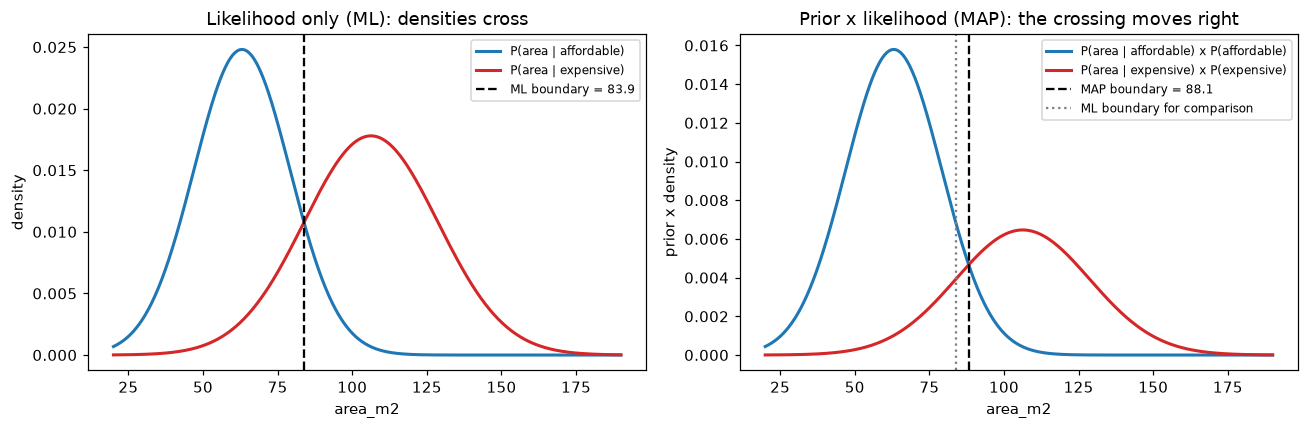

the prior shifts the decision boundary by 4.3 m2
larger area is now required before 'expensive' wins, because that class is rarer


In [78]:
feature_index = 0                                            # area_m2, the first continuous feature
x_grid = np.linspace(20, 190, 600)

lik_0 = gaussian_pdf(x_grid, means[0, feature_index], stds[0, feature_index])
lik_1 = gaussian_pdf(x_grid, means[1, feature_index], stds[1, feature_index])

weighted_0 = prior_hat[0] * lik_0                            # P(x|c) P(c): what MAP compares
weighted_1 = prior_hat[1] * lik_1

between_means = (x_grid >= means[0, feature_index]) & (x_grid <= means[1, feature_index])

boundary_ml = x_grid[between_means][np.argmin(np.abs(lik_0 - lik_1)[between_means])]
boundary_map = x_grid[between_means][np.argmin(np.abs(weighted_0 - weighted_1)[between_means])]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

axes[0].plot(x_grid, lik_0, color="tab:blue", lw=2, label="P(area | affordable)")
axes[0].plot(x_grid, lik_1, color="tab:red", lw=2, label="P(area | expensive)")
axes[0].axvline(boundary_ml, ls="--", color="black", label=f"ML boundary = {boundary_ml:.1f}")
axes[0].set_title("Likelihood only (ML): densities cross")
axes[0].set_xlabel("area_m2"); axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)

axes[1].plot(x_grid, weighted_0, color="tab:blue", lw=2, label="P(area | affordable) x P(affordable)")
axes[1].plot(x_grid, weighted_1, color="tab:red", lw=2, label="P(area | expensive) x P(expensive)")
axes[1].axvline(boundary_map, ls="--", color="black", label=f"MAP boundary = {boundary_map:.1f}")
axes[1].axvline(boundary_ml, ls=":", color="grey", label="ML boundary for comparison")
axes[1].set_title("Prior x likelihood (MAP): the crossing moves right")
axes[1].set_xlabel("area_m2"); axes[1].set_ylabel("prior x density"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"the prior shifts the decision boundary by {boundary_map - boundary_ml:.1f} m2")
print("larger area is now required before 'expensive' wins, because that class is rarer")

**Line by line**

- Only `area_m2` is used here so the picture stays one-dimensional and the boundary is a single point
  rather than a surface.
- `prior_hat[c] * lik_c` : the exact quantity MAP compares, in probability space rather than log space.
  Multiplying by a constant less than 1 pushes a whole curve down without changing its shape.
- `between_means` : a boolean mask restricting the search to the interval between the two class means,
  and **this restriction is essential**. Two Gaussians with different standard deviations cross *twice*,
  and far out in the right tail both densities are so close to zero that their difference is smaller than
  it is at the crossing we care about. An unrestricted `argmin` would happily report the edge of the grid
  as the "boundary". Whenever you locate a crossing numerically, bound the search to the region where the
  crossing you want actually lives.
- `x_grid[between_means][np.argmin(np.abs(lik_0 - lik_1)[between_means])]` : the "find the nearest" idiom
  from Part 3, applied inside that window: mask the grid, mask the differences, take the `argmin`, index
  back. That crossing point *is* the decision boundary — on one side one class scores higher, on the
  other side the other does.
- `sharey=False` : the two panels have genuinely different vertical scales (the right one is scaled down
  by the priors), so forcing a shared axis would flatten one of them.

**Reading it.** The left panel's boundary is where the two class-conditional densities are equal, around
84 m². The right panel scales the blue curve by 0.64 and the red by 0.36, and the crossing moves right to
about 88 m². The rarer class now has to work harder: an apartment must be about 4 m² larger before the
evidence overcomes the prior. **That shift is the prior, made visible.**

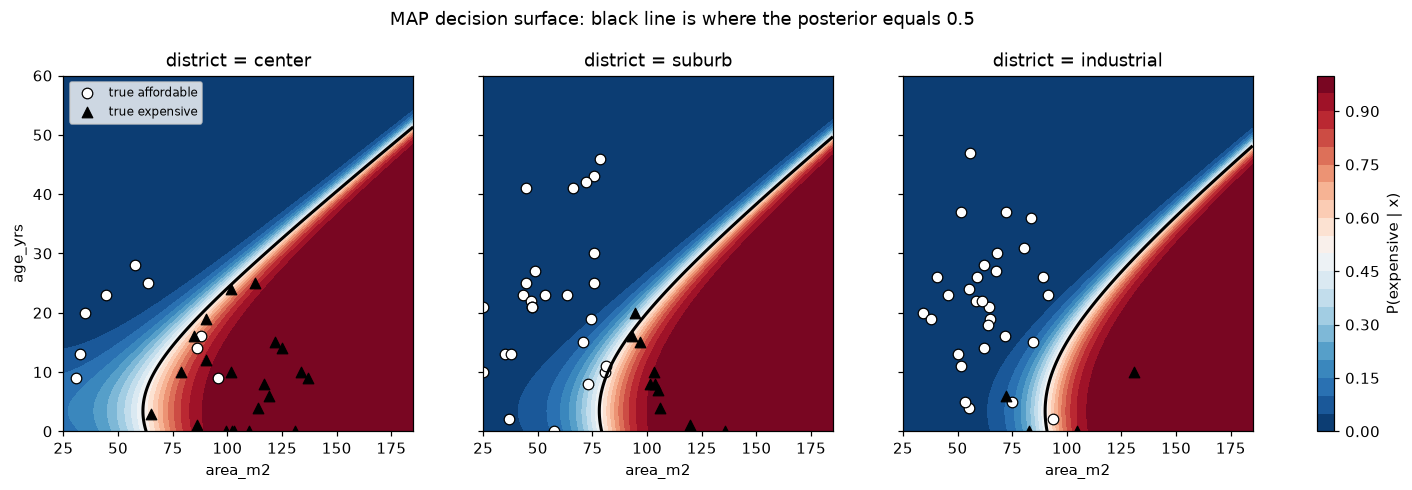

In [79]:
grid_area = np.linspace(25, 185, 220)                        # x axis of the decision surface
grid_age = np.linspace(0, 60, 220)                           # y axis
mesh_area, mesh_age = np.meshgrid(grid_area, grid_age)       # two (220, 220) coordinate grids

flat_points = np.column_stack([mesh_area.ravel(), mesh_age.ravel()])   # (48400, 2) list of points

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, fixed_district in zip(axes, DISTRICTS):
    districts_flat = np.array([fixed_district] * len(flat_points))     # hold the district constant
    grid_scores = joint_log_score(flat_points, districts_flat)
    grid_posterior = log_scores_to_posterior(grid_scores)[:, 1]        # P(expensive | x)
    surface = grid_posterior.reshape(mesh_area.shape)                  # back to (220, 220)

    contour = ax.contourf(mesh_area, mesh_age, surface, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
    ax.contour(mesh_area, mesh_age, surface, levels=[0.5], colors="black", linewidths=2)

    for c, marker, face in ((0, "o", "white"), (1, "^", "black")):     # one call per true class
        keep = (d_test == fixed_district) & (y_test == c)              # this district AND this class
        ax.scatter(Xc_test[keep, 0], Xc_test[keep, 1],
                   marker=marker, facecolor=face, edgecolor="black",
                   s=48, linewidth=0.8, label=f"true {CLASS_NAMES[c]}")

    ax.set_title(f"district = {fixed_district}")
    ax.set_xlabel("area_m2")

axes[0].set_ylabel("age_yrs")
axes[0].legend(fontsize=8, loc="upper left")
plt.colorbar(contour, ax=axes, label="P(expensive | x)", fraction=0.02)
plt.suptitle("MAP decision surface: black line is where the posterior equals 0.5", y=1.02)
plt.show()

**Line by line**

- `np.meshgrid(a, b)` : turns two 1-D axes into two 2-D coordinate arrays, so that `mesh_area[i, j]` and
  `mesh_age[i, j]` together give the coordinates of grid cell `(i, j)`. This is the standard way to
  evaluate a function over a rectangle.
- `.ravel()` : flattens a 2-D array into 1-D. `np.column_stack` then pairs the flattened coordinates into
  a list of `(area, age)` points, because `joint_log_score` expects a matrix of rows, not a grid.
- `.reshape(mesh_area.shape)` : folds the flat vector of 48400 posteriors back into the grid so it can be
  drawn. **Flatten, compute, reshape** is the general recipe for evaluating any model over a 2-D region.
- `ax.contourf(...)` : filled contours, colouring each region by posterior probability.
  `ax.contour(..., levels=[0.5])` draws a single line at the 0.5 contour: **the decision boundary**.
- One panel per district, because the district is a third feature that cannot be drawn on a 2-D plane.
  Fixing it and drawing three panels shows what it does: it shifts the entire boundary.
- The inner loop draws the test points in two passes, one per true class, so each gets its own marker
  shape and fill. Shape plus fill survives being drawn on top of a strongly coloured background far
  better than colour alone would: a white circle sitting in deep red territory is a visible mistake.
- `(d_test == fixed_district) & (y_test == c)` : two conditions combined, so each pass draws only the
  test apartments that belong in this panel *and* in this class.

**Reading it.** The boundary is a smooth curve, not a straight line, because the two classes have
different standard deviations; equal variances would give exactly a straight line, which is worth
proving to yourself in Exercise 4. Moving from `center` to `industrial` shifts the whole boundary right:
in the industrial district an apartment must be much larger before the classifier is willing to call it
expensive, because the prior-times-likelihood for `expensive` starts from a much weaker position there.

In [80]:
print(f"{'assumed P(expensive)':>22} | {'# predicted expensive':>21} | {'accuracy':>8}")
print("-" * 58)

for assumed_p1 in [0.02, 0.10, 0.25, prior_hat[1], 0.50, 0.75, 0.95]:
    assumed_prior = np.array([1.0 - assumed_p1, assumed_p1])          # a full two-entry prior
    adjusted = scores_test - log_prior + np.log(assumed_prior)        # swap the old prior for the new one
    predictions = adjusted.argmax(axis=1)
    label = f"{assumed_p1:.3f}" + (" (estimated)" if np.isclose(assumed_p1, prior_hat[1]) else "")
    print(f"{label:>22} | {predictions.sum():>21} | {(predictions == y_test).mean():>8.3f}")

  assumed P(expensive) | # predicted expensive | accuracy
----------------------------------------------------------
                 0.020 |                    19 |    0.820
                 0.100 |                    26 |    0.890
                 0.250 |                    32 |    0.910
     0.363 (estimated) |                    36 |    0.930
                 0.500 |                    38 |    0.910
                 0.750 |                    41 |    0.920
                 0.950 |                    50 |    0.850


**Line by line**

- `scores_test - log_prior + np.log(assumed_prior)` : subtract the log of the prior that was used, add
  the log of the one we want. In probability space this is dividing out one factor and multiplying in
  another; in log space it is two additions and needs no refitting. **The likelihoods are untouched**,
  which is the point: the prior can be changed after training, and only the prior changes.
- `predictions.sum()` : since the labels are `0` and `1`, summing counts how many rows were called
  `expensive`.
- The f-string alignment specifiers (`:>22`, `:>8.3f`) line the columns up. `>` means right-aligned, the
  number is the field width.

**Reading the table.** As the assumed prior rises, the classifier predicts `expensive` more often, and
accuracy peaks near the prior actually present in the data. Push the prior to 0.02 and the classifier
becomes so sceptical that it misses genuinely expensive apartments; push it to 0.95 and it calls almost
everything expensive.

**Two honest caveats.** First, this table is computed on the test set, so reading off the best value
would be tuning on data that is supposed to be untouched. Second and more useful; a deliberately
"wrong" prior is sometimes the right engineering choice. If missing an expensive apartment costs your
client far more than a false alarm, raising the prior buys recall at the cost of precision. **The prior
is the honest place to encode what you believe and what errors cost**, rather than quietly nudging a
threshold elsewhere.

---
## Summary

| concept | formula | code in this notebook | check that it is right |
|---|---|---|---|
| empirical PMF | $\hat{P}(v) = \text{count}(v)/n$ | `counts / counts.sum()` | sums to 1 |
| density from histogram | mass / bin width | `prob_per_bin / bin_width` | area sums to 1 |
| fitted Gaussian | $\hat\mu, \hat\sigma$ | `.mean()`, `.std(ddof=0)` | integrates to 1 |
| joint | $P(A, B)$ | `crosstab(..., normalize=True)` | whole table sums to 1 |
| marginal | $P(A) = \sum_b P(A, b)$ | `joint.sum(axis=1)` or `joint @ ones` | sums to 1 |
| conditional | $P(A \mid B) = P(A,B)/P(B)$ | `joint / marg[:, None]` | each row sums to 1 |
| independence | $P(A,B) = P(A)P(B)$ | `np.outer(p, q)` | compare against the joint |
| product rule | $P(A,B) = P(A \mid B)P(B)$ | elementwise `*` | holds exactly |
| Bayes rule | $P(C \mid x) \propto P(x \mid C)P(C)$ | `prior * likelihood`, then normalise | posterior sums to 1 |
| evidence | $P(x) = \sum_c P(x \mid c)P(c)$ | `(prior * lik).sum()` | the normalising constant |
| naive Bayes | $P(x \mid c) = \prod_j P(x_j \mid c)$ | sum of `log_...` terms | log space, no underflow |
| MAP decision | $\arg\max_c P(x \mid c)P(c)$ | `scores.argmax(axis=1)` | evidence cancels |
| ML decision | $\arg\max_c P(x \mid c)$ | `(scores - log_prior).argmax(1)` | differs on borderline cases |
| Laplace smoothing | $\frac{\text{count} + \alpha}{\text{total} + \alpha K}$ | `(counts + 1) / (total + 3)` | rows still sum to 1 |

**The one sentence version:** a joint distribution is a table that sums to one, marginalising is summing
along an axis, conditioning is normalising a slice, Bayes rule flips the direction of a conditional at
the cost of supplying a prior, and a classifier is nothing more than the argmax of prior times
likelihood.

**How this connects to the previous practical.** There, a prediction was a dot product `Phi @ w` and the
answer was a single number with no uncertainty attached. Here, a prediction is a full distribution over
classes, and the decision is only the last step, an argmax taken over it. The scoring function still has
the same shape: a baseline (the log prior, previously the bias) plus a sum of per-feature contributions
(log likelihoods, previously `value × weight`). What is new is that every term is now a probability, so
the model can say **how sure it is**, not just what it thinks.

---
# Exercises

Four exercises, roughly in order of difficulty. Write your code in the empty cell below each one. Every
exercise uses only functions and variables already defined above, so nothing new needs to be imported.

**Before you start, a habit worth keeping.** After computing any distribution, print its sum. A joint
must total 1, each row of a conditional must total 1, and a posterior must total 1. Most errors in
probability code announce themselves immediately in that one number.

## Exercise 1: A joint distribution of your own

The notebook analysed `district` against `size_class`. Do the same analysis for **`age_class` against
`district`**.

1. Create a new column `age_class` by binning `age_yrs` into `"new"` for 15 years or less and `"old"`
   above 15. Use `pd.cut` with edges `[-0.1, 15, np.inf]` (the `-0.1` ensures a brand-new apartment aged
   `0` is included in the first bin).
2. Build the joint distribution $P(\text{age\_class}, \text{district})$ as a 2×3 NumPy array by counting
   combinations, and confirm it sums to 1.
3. Compute both marginals, $P(\text{age\_class})$ and $P(\text{district})$. Verify that the district
   marginal matches `marg_district` computed earlier in the notebook.
4. Compute **both** conditionals: $P(\text{district} \mid \text{age\_class})$ and
   $P(\text{age\_class} \mid \text{district})$. Be careful about which axis you normalise over, and
   confirm the correct axis sums to 1 in each case.
5. Test independence with `np.outer` and report the largest absolute deviation. State in one sentence
   whether age and district are independent in this dataset, and what that means for a classifier.

*Hint for step 4:* one of the two conditionals divides by a column vector shaped `(2, 1)`, the other
divides by a row vector shaped `(1, 3)`. Getting the shapes right is the whole exercise.

In [81]:
# Your code for Exercise 1

## Exercise 2: Bayes rule with a new piece of evidence

An estate agent adds a `premium_listing` flag to some apartments. From historical records:

- $P(\text{flag} \mid \text{expensive}) = 0.70$
- $P(\text{flag} \mid \text{affordable}) = 0.15$

Use the prior estimated from the training data, `prior_hat`, and the `bayes_posterior` function already
defined in Part 3.

1. An apartment carries the flag. Compute $P(\text{expensive} \mid \text{flag})$. Before running the
   code, write down your guess as a comment and see how close you were.
2. A different apartment does **not** carry the flag. Compute $P(\text{expensive} \mid \text{no flag})$.
   You will need the likelihoods of *not* seeing the flag, which are one minus the numbers above.
3. Suppose three **independent** appraisers each apply this flag and all three agree that it applies.
   Update the belief three times sequentially, feeding each posterior in as the next prior. Print the
   belief after each step. How many positive flags are needed before the posterior first exceeds 0.90?
4. Now combine this flag with the district evidence from Part 3c: an apartment is in the `industrial`
   district **and** carries the flag. Assuming the flag and the district are conditionally independent
   given the class, compute the posterior. Does the flag rescue the industrial district's very low
   prior belief?
5. Plot $P(\text{expensive} \mid \text{flag})$ as the assumed value of
   $P(\text{flag} \mid \text{affordable})$ varies from 0.01 to 0.60, holding everything else fixed. What
   does the shape of the curve say about how much a test's false-positive rate matters?

*Hint for step 4:* conditional independence means the two likelihoods multiply, exactly as the two damp
tests did in Part 3b.

In [82]:
# Your code for Exercise 2

## Exercise 3: Changing the classifier's feature set

The classifier in Part 4 used three features: `area_m2`, `age_yrs` and `district`. Investigate what each
one contributes, and what happens when a redundant feature is added.

1. Retrain and evaluate a MAP classifier using **only** `district`. Since it has a single discrete
   feature, this needs nothing more than `prior_hat`, `log_lik_district` and an `argmax`. Report its
   test accuracy and compare it against the majority-class baseline.
2. Retrain using **only** the two continuous features, dropping `district` entirely. Report test
   accuracy. Which single feature is doing most of the work?
3. Now add `size_class` as a **fourth** feature, alongside the existing three, treating it as a discrete
   feature with its own Laplace-smoothed likelihood table. Report the test accuracy and the average
   value of $\max_c P(c \mid x)$, the classifier's confidence in its own answer.
4. `size_class` was derived from `area_m2` by binning, so it carries almost no information that
   `area_m2` did not already carry. Explain what this does to the naive Bayes conditional independence
   assumption, and why the classifier's **confidence** changes more than its **accuracy**. This is the
   single most important practical failure mode of naive Bayes, so answer it in a full paragraph.

*Hint for step 3:* write a function that takes a list of discrete feature arrays and a list of continuous
column indices, so you can build several classifiers without copying code. The pattern to reuse is
`joint_log_score`: start from `log_prior`, then add one log-likelihood term per feature.

In [83]:
# Your code for Exercise 3

## Exercise 4: The prior, the boundary, and class imbalance

Two related investigations into what the prior and the class-conditional variances control.

1. **A straight boundary.** Refit the Gaussian parameters but force both classes to share a single
   **pooled** standard deviation per feature, computed across the whole training set rather than within
   each class. Keep the means class-specific. Redraw the 2-D decision surface from Part 4d for one
   district. Confirm the 0.5 contour is now a straight line, and explain in a sentence or two why equal
   variances remove the curvature. (The quadratic terms $x^2/2\sigma_c^2$ become identical across the
   classes and cancel in the difference of the two log scores.)
2. **Deliberate imbalance.** Build an imbalanced training set by keeping every `affordable` row but only
   a random 20% of the `expensive` rows. Re-estimate the prior, the likelihoods, and everything else on
   this reduced training set, then evaluate on the **original, untouched** test set.
   - Report MAP accuracy, ML accuracy, and the confusion matrix for both.
   - How many genuinely expensive test apartments does each rule find? Compute precision and recall for
     the `expensive` class under both.
   - Which rule would you deploy if a missed expensive apartment costs ten times as much as a false
     alarm? Justify your answer using the numbers, not intuition.
3. **Correcting a known imbalance.** Keep the likelihoods estimated from the imbalanced data, but
   substitute the *true* prior `TRUE_PRIOR` back into the score, using the
   `scores - log_prior + np.log(new_prior)` trick from the end of Part 4d. Does accuracy on the test set
   recover? Explain what this tells you about which parts of a naive Bayes model are damaged by
   imbalanced training data and which parts survive it intact.

*Hint for step 2:* `rng.choice(indices, size=k, replace=False)` selects a random subset without
repetition. Make sure you only reduce the **training** set, never the test set, or the evaluation
becomes meaningless.

In [84]:
# Your code for Exercise 4